In [ ]:
import pandas as pd

df = pd.read_csv('/content/ev_charging_dataset.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())

Dataset loaded successfully. Displaying the first 5 rows:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitud

In [ ]:
import pandas as pd
import os

file_path = '/content/ev_charging_dataset.csv'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the 'ev_charging_dataset.csv' file is uploaded to the '/content/' directory.")
else:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    print(df.head())

Dataset loaded successfully. Displaying the first 5 rows:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitud

In [ ]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())

print("\nGetting information about data types and non-null values:")
df.info()

print("\nGenerating descriptive statistics for numerical columns:")
print(df.describe())

Displaying the first 5 rows of the DataFrame:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitude  Destinati

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing Values Information:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Missing Values Information:
                            Missing Count  Missing Percentage
Destination_Latitude                    1             0.00248
Destination_Longitude                   1             0.00248
Distance_to_Destination_km              1             0.00248
Traffic_Data                            1             0.00248
Road_Conditions                         1             0.00248
Charging_Station_ID                     1             0.00248
Charging_Rate_kW                        1             0.00248
Queue_Time_mins                         1             0.00248
Station_Capacity_EV                     1             0.00248
Time_Spent_Charging_mins                1             0.00248
Energy_Drawn_kWh                        1             0.00248
Session_Start_Hour                      1             0.00248
Fleet_Size                              1             0.00248
Fleet_Schedule                          1             0.00248
Temperature_C                           1 

In [ ]:
df_cleaned = df.dropna()
print("Shape of DataFrame before dropping missing values:", df.shape)
print("Shape of DataFrame after dropping missing values:", df_cleaned.shape)

print("\nVerifying missing values after dropping:")
print(df_cleaned.isnull().sum().sum())


Shape of DataFrame before dropping missing values: (40315, 28)
Shape of DataFrame after dropping missing values: (40314, 28)

Verifying missing values after dropping:
0


In [ ]:
df_cleaned['Date_Time'] = pd.to_datetime(df_cleaned['Date_Time'])

# Identify numerical columns for histograms
# Exclude 'Vehicle_ID' and 'Session_Start_Hour' (constant) and 'Destination_Longitude' (erroneous value)
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
exclude_numerical = ['Vehicle_ID', 'Session_Start_Hour', 'Destination_Longitude']
numerical_cols = [col for col in numerical_cols if col not in exclude_numerical]

# Identify categorical columns for bar plots
categorical_cols = ['Road_Conditions', 'Weather_Conditions', 'Fleet_Schedule', 'Weekday', 'Charging_Preferences', 'Traffic_Data']

print("Identified numerical columns for histograms:", numerical_cols)
print("Identified categorical columns for bar plots:", categorical_cols)

Identified numerical columns for histograms: ['Battery_Capacity_kWh', 'State_of_Charge_%', 'Energy_Consumption_Rate_kWh/km', 'Current_Latitude', 'Current_Longitude', 'Destination_Latitude', 'Distance_to_Destination_km', 'Traffic_Data', 'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins', 'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C', 'Wind_Speed_m/s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences', 'Charging_Load_kW']
Identified categorical columns for bar plots: ['Road_Conditions', 'Weather_Conditions', 'Fleet_Schedule', 'Weekday', 'Charging_Preferences', 'Traffic_Data']


/tmp/ipykernel_3183/1811784578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date_Time'] = pd.to_datetime(df_cleaned['Date_Time'])


Generating histograms for numerical columns...


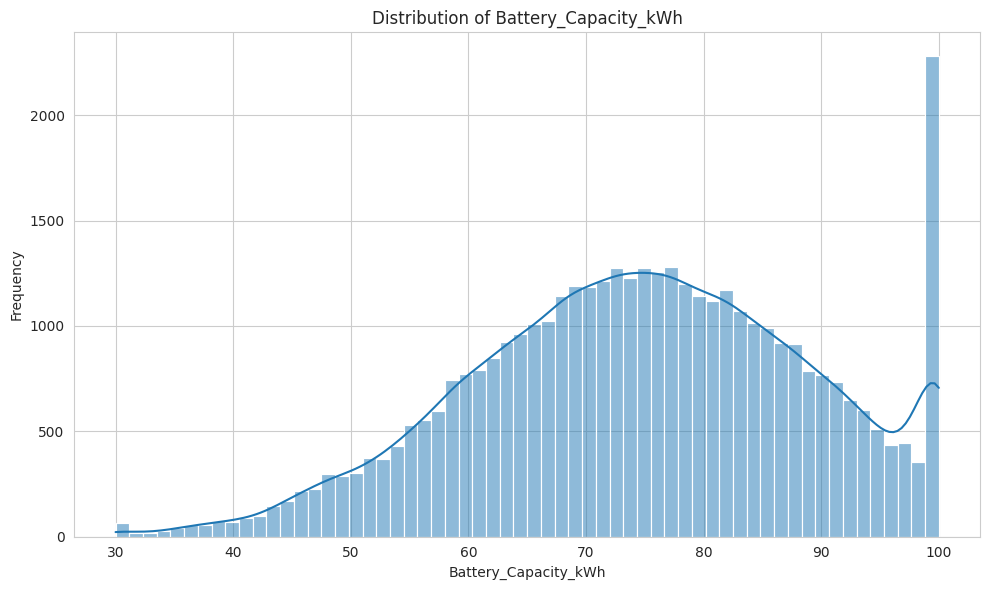

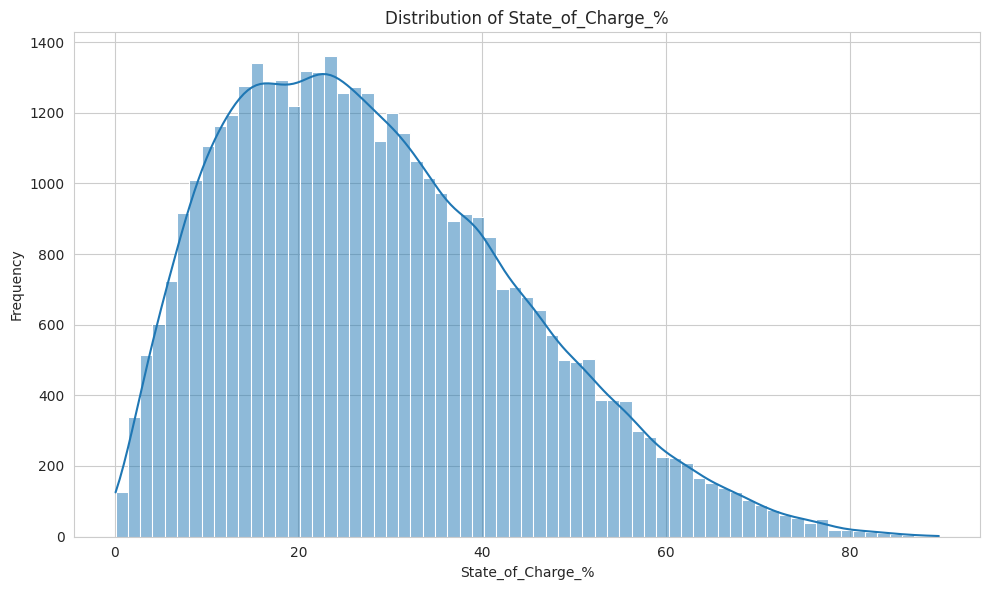

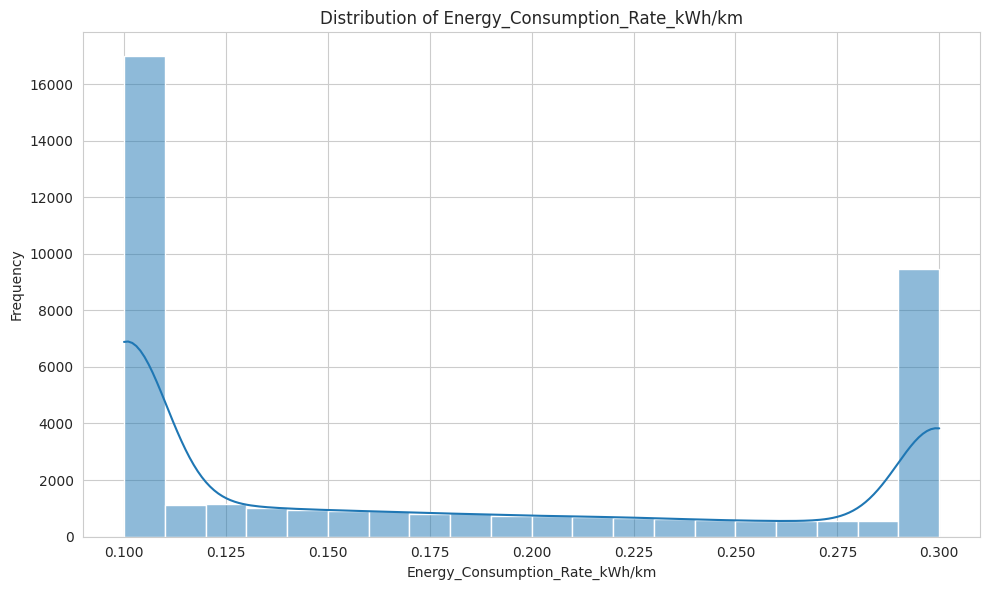

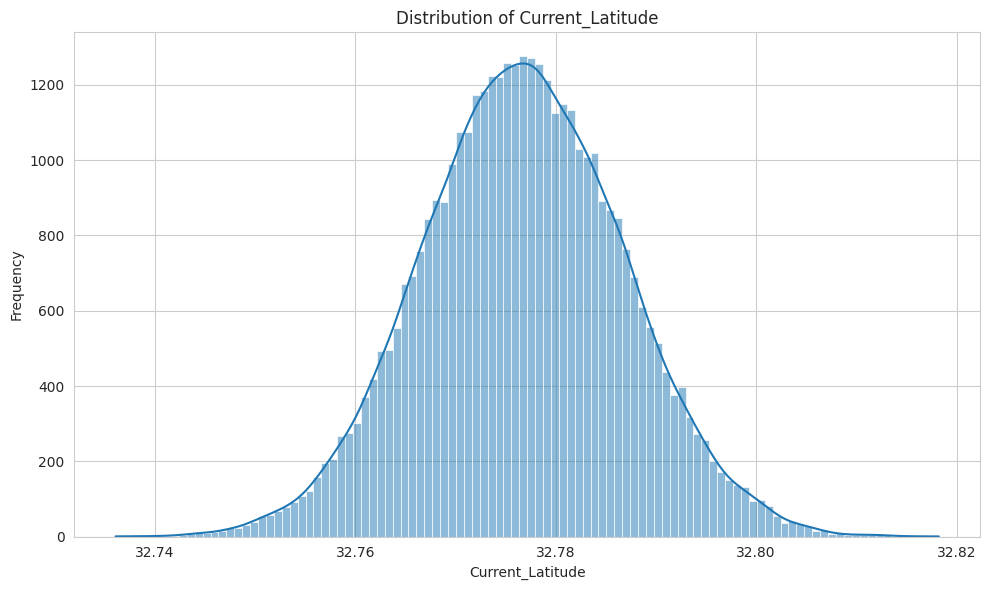

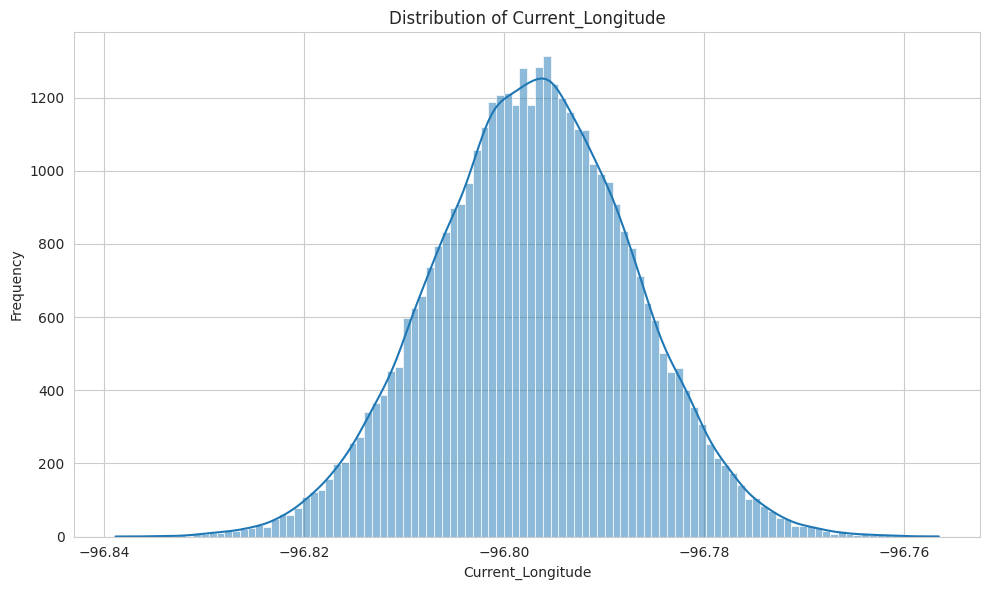

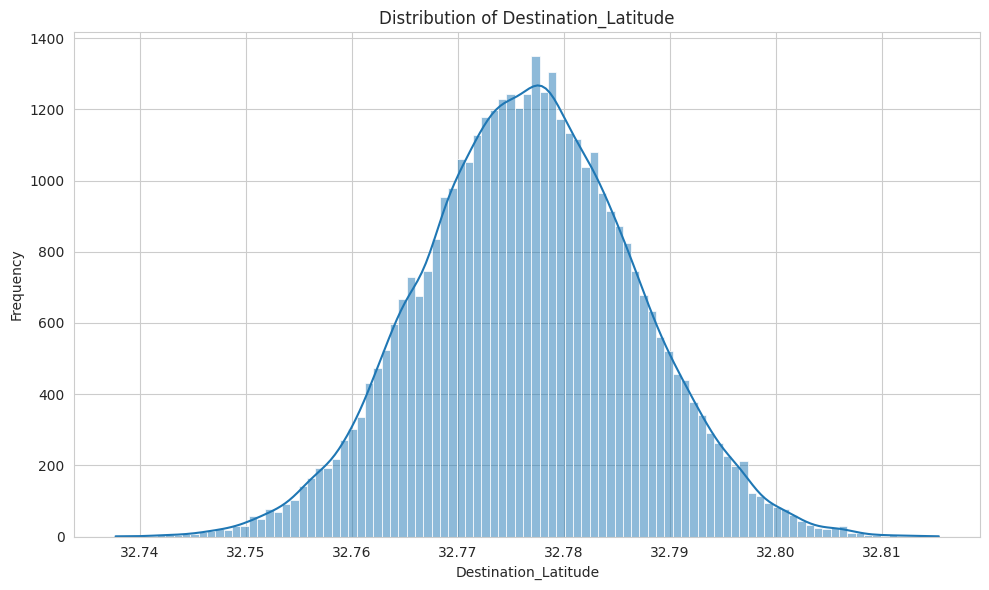

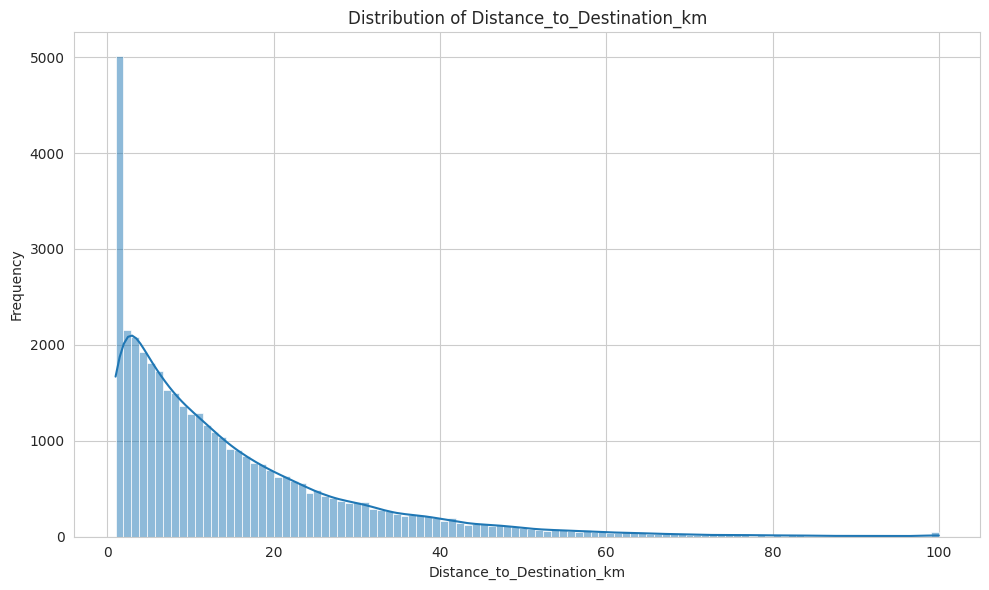

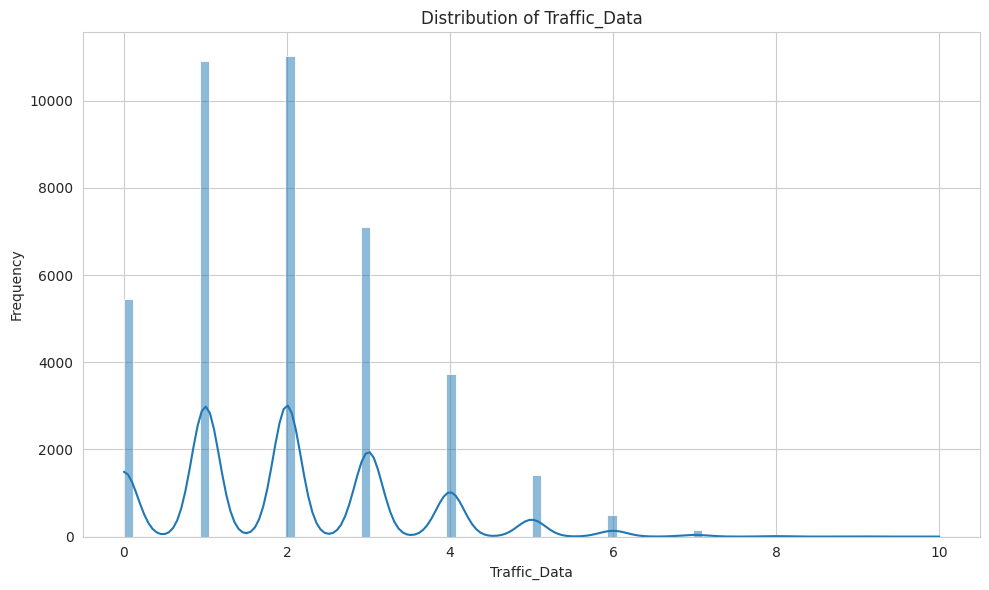

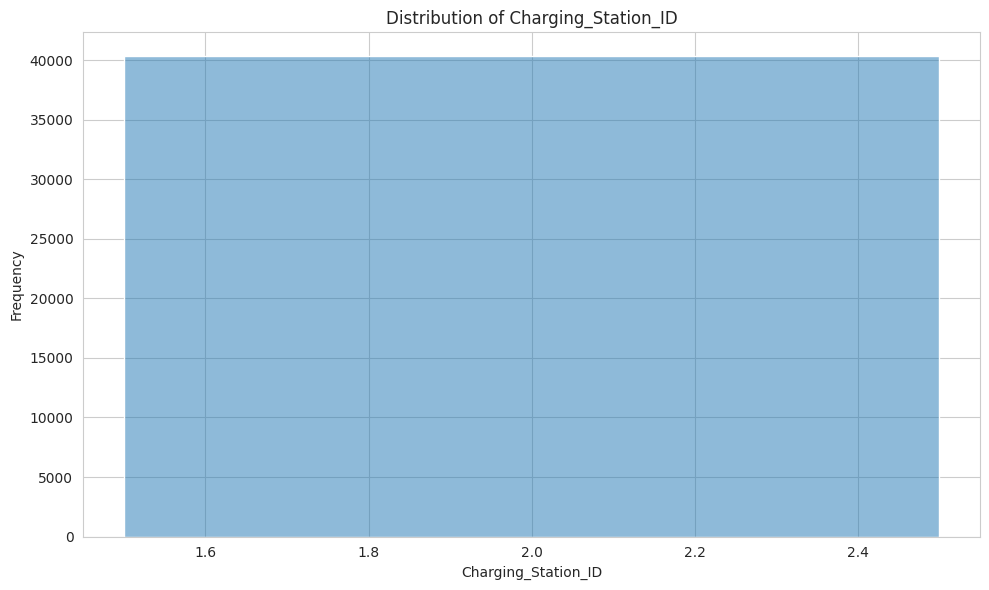

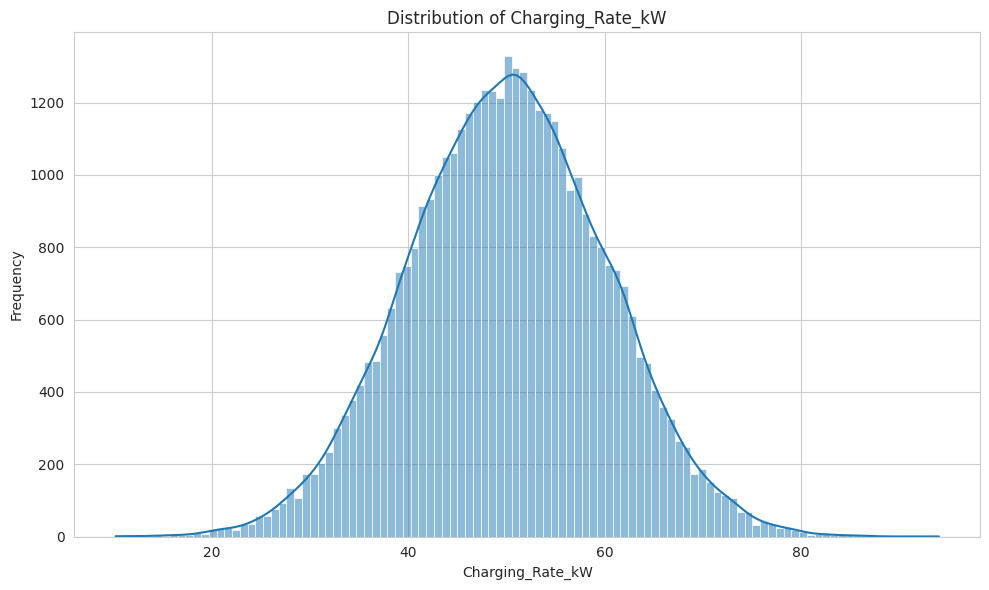

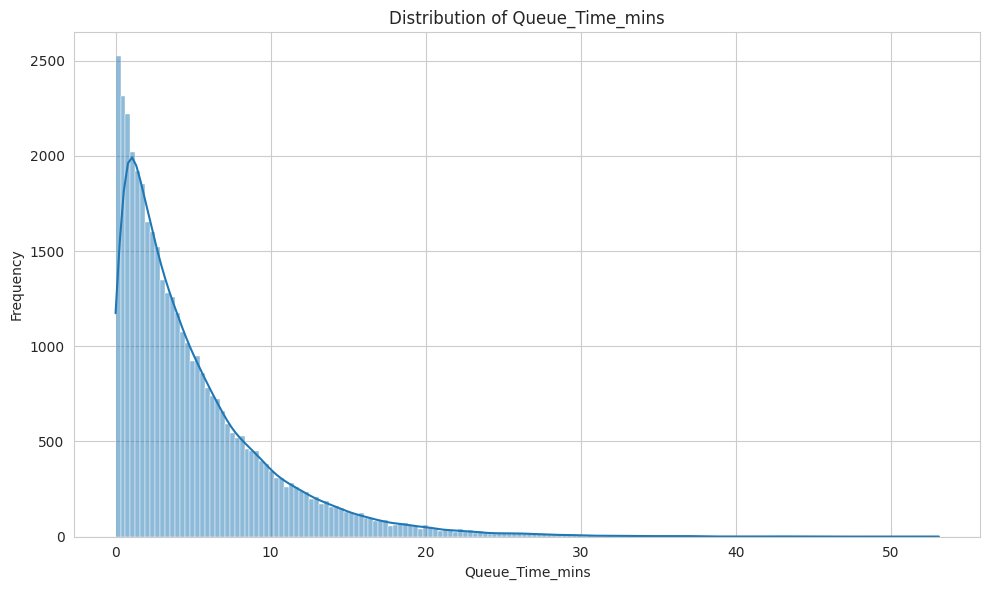

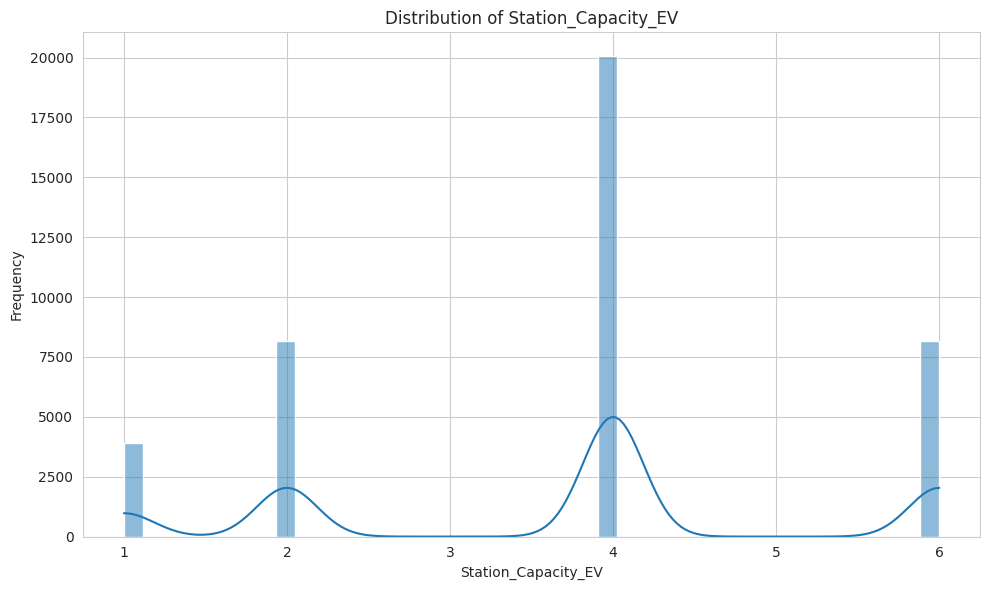

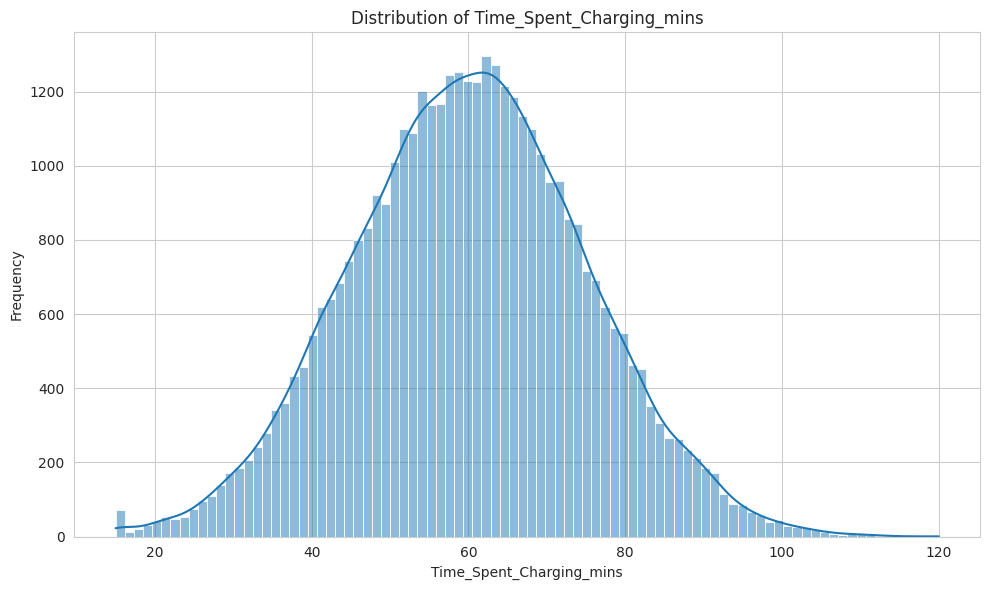

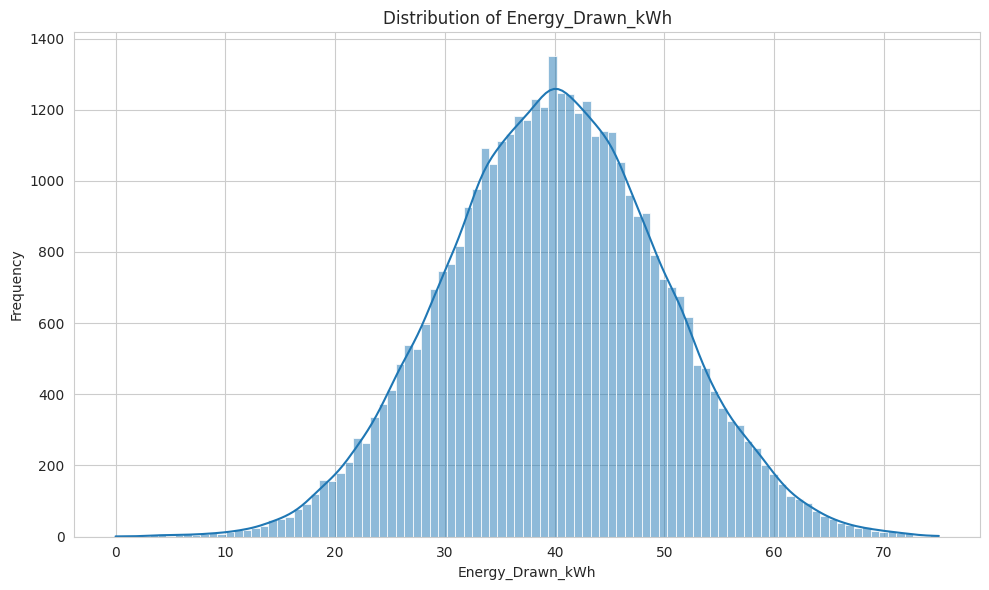

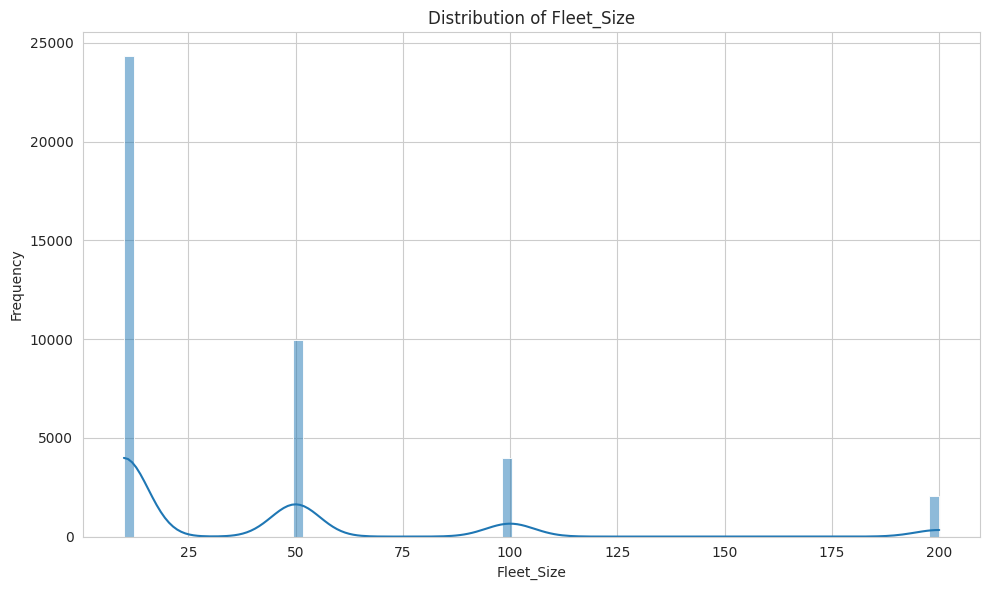

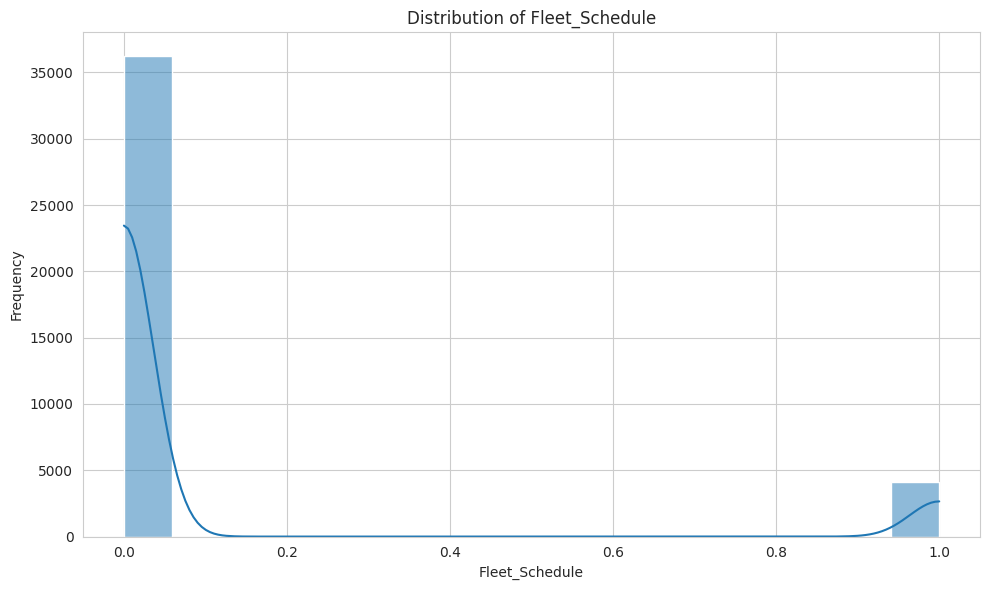

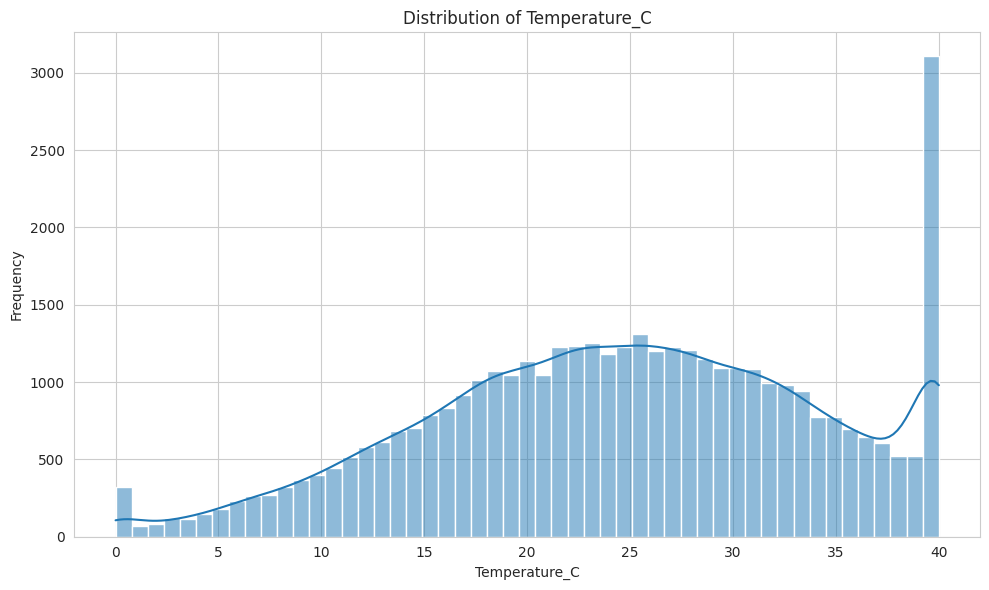

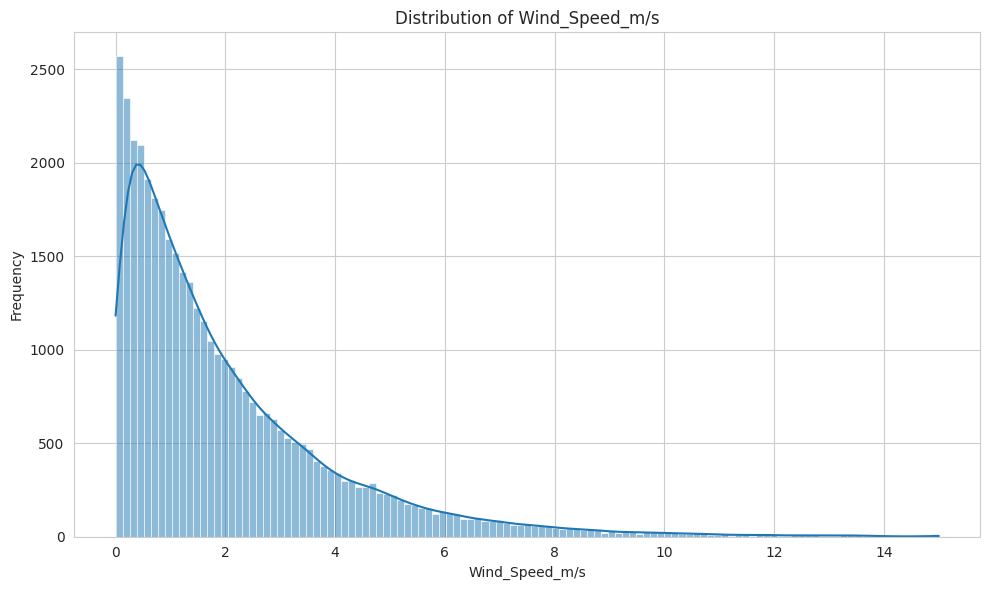

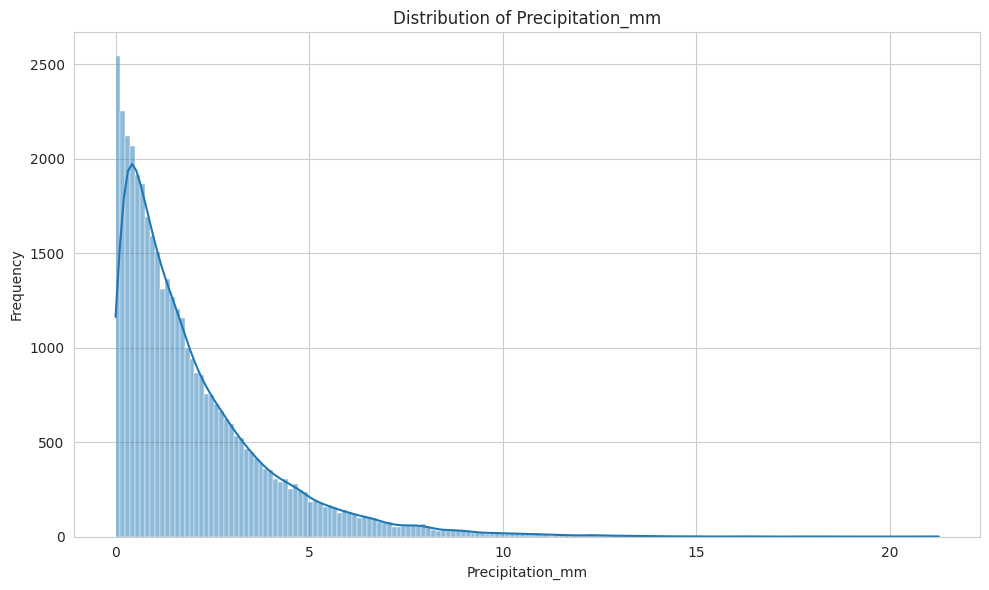

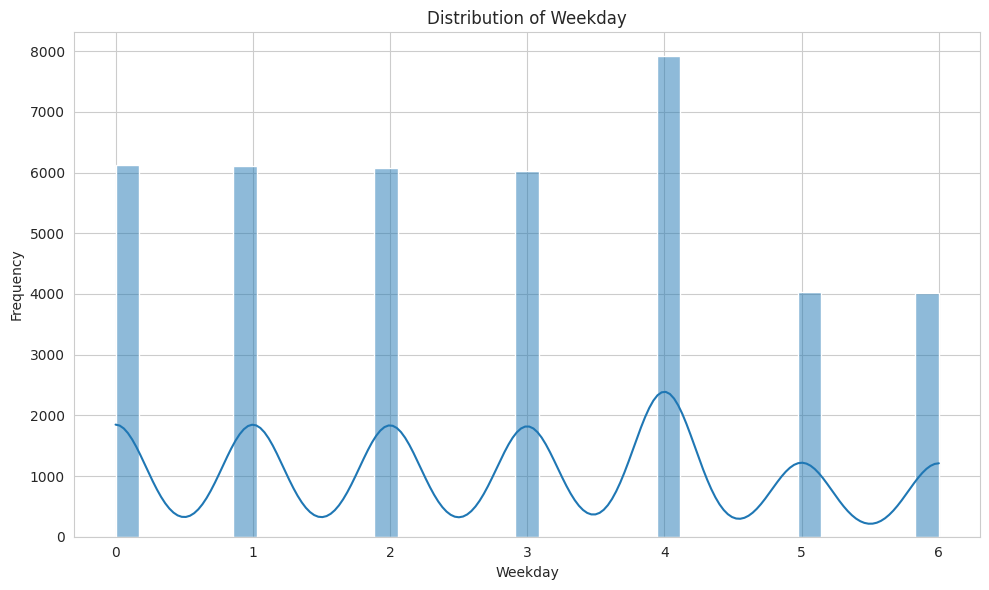

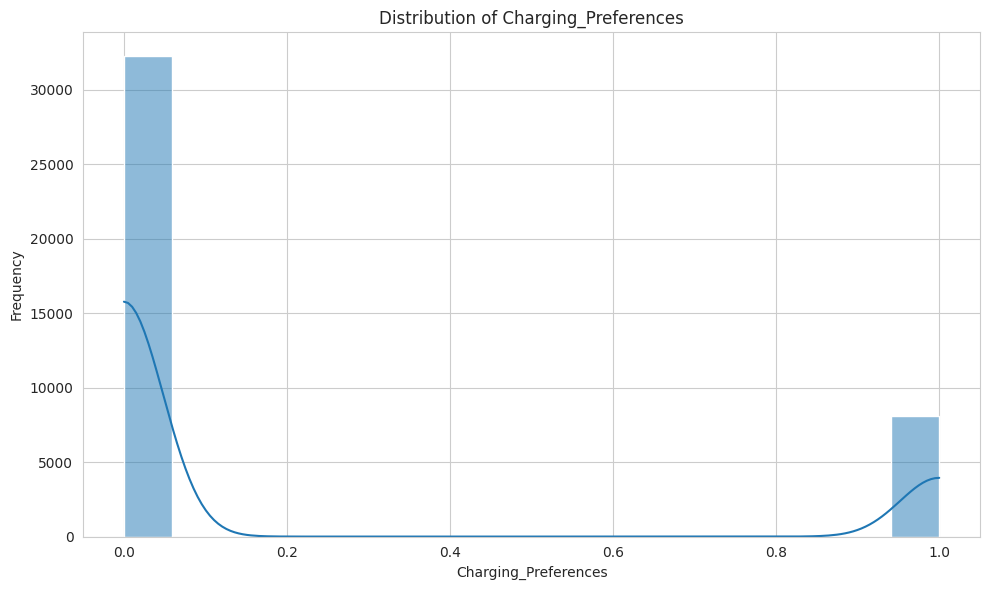

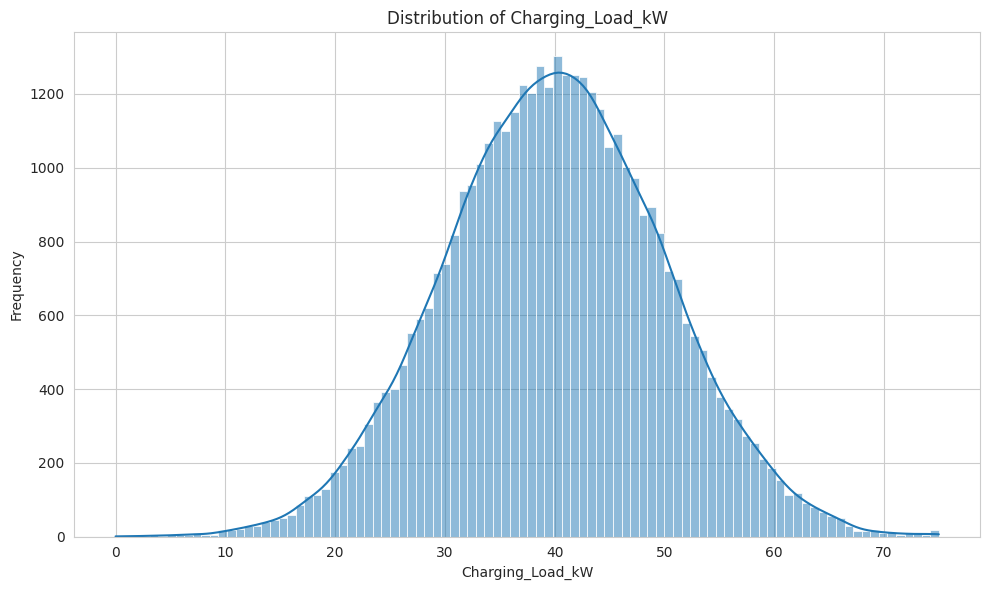


Generating bar plots for categorical columns...


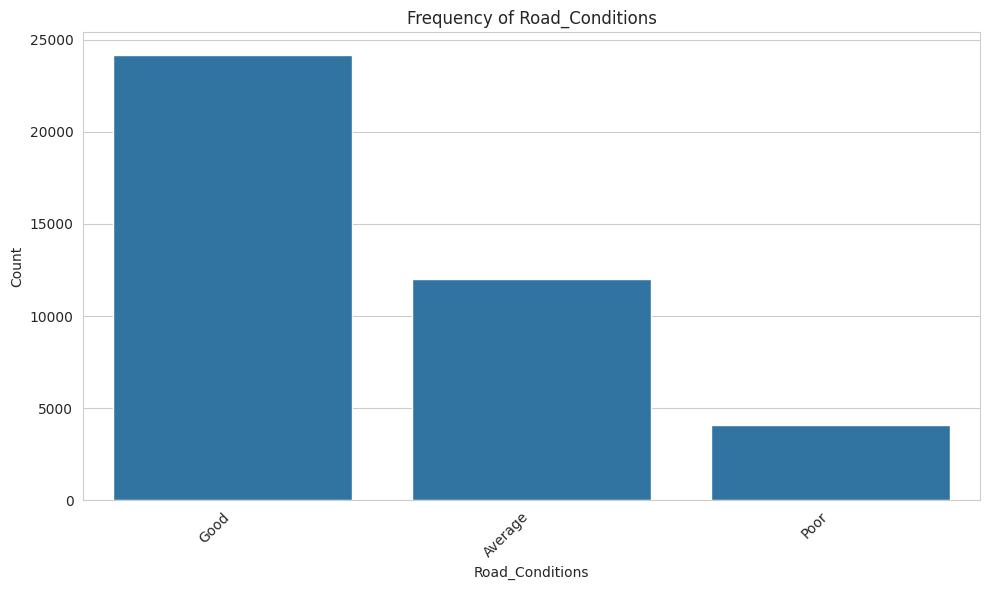

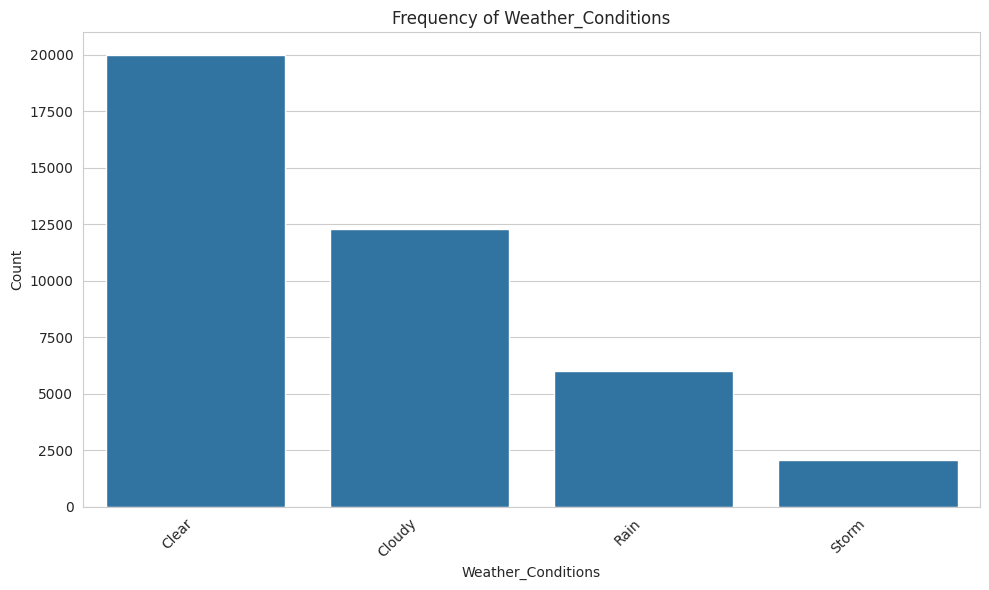

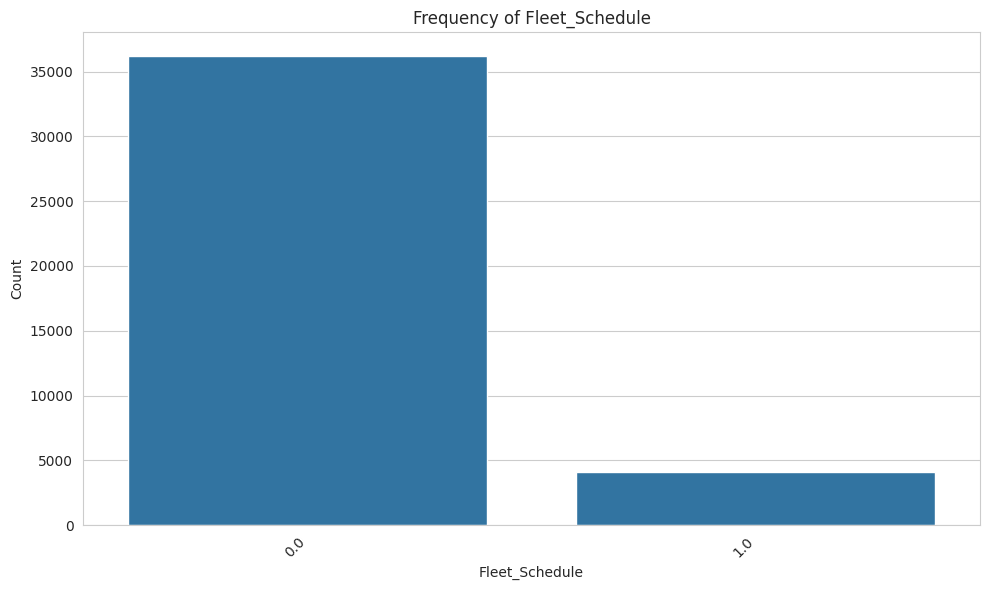

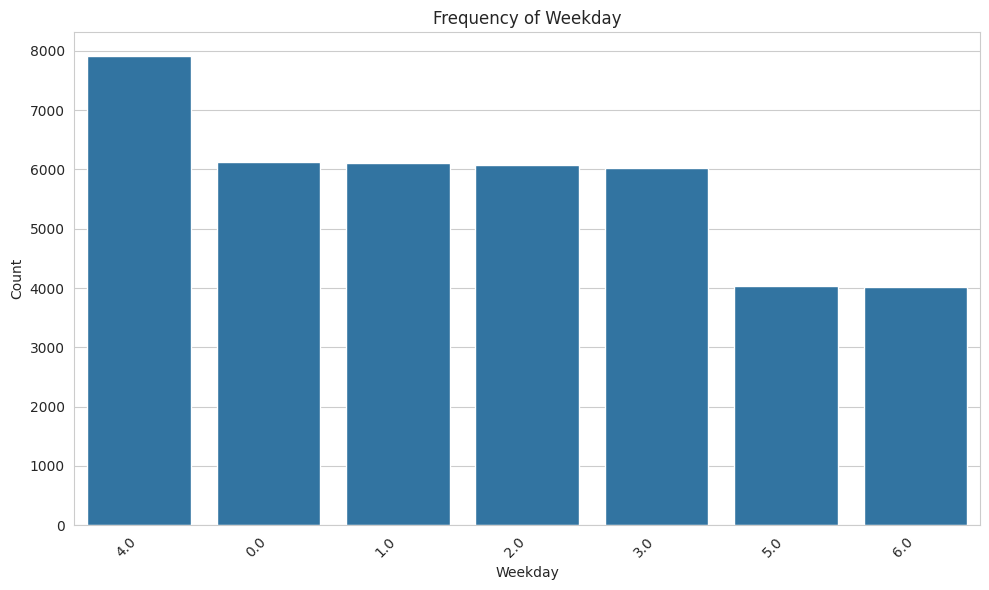

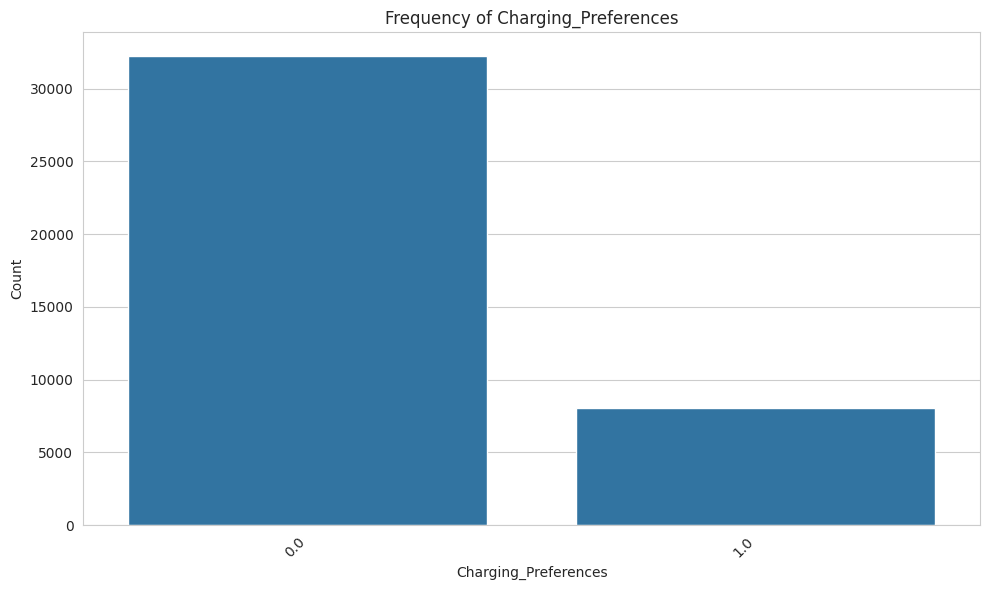

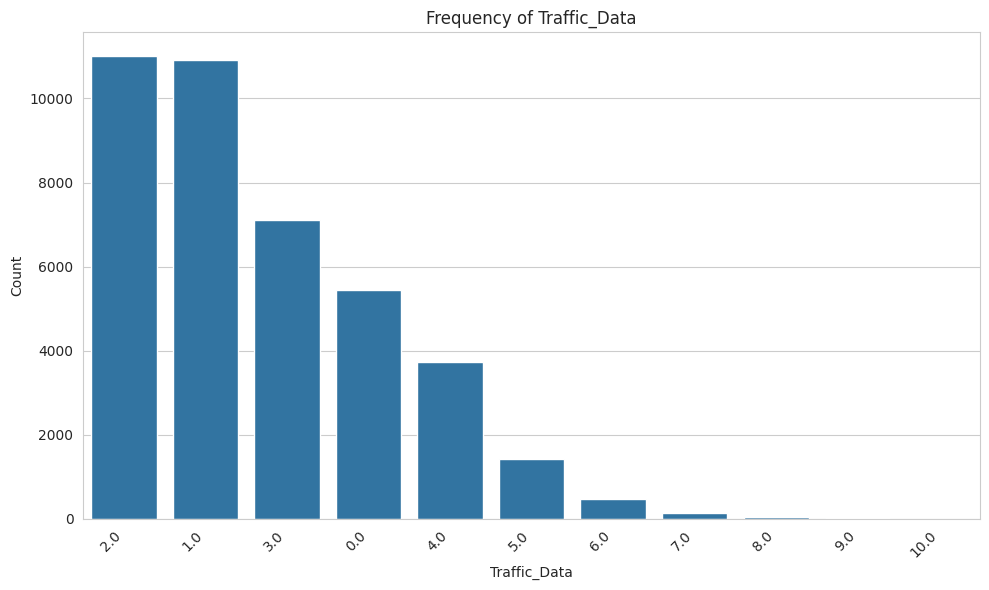

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for plots
sns.set_style("whitegrid")

# Plot histograms for numerical columns
print("Generating histograms for numerical columns...")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Plot bar plots for categorical columns
print("\nGenerating bar plots for categorical columns...")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_cleaned, x=col, order=df_cleaned[col].value_counts().index)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

Generating scatter plots for numerical variable pairs...


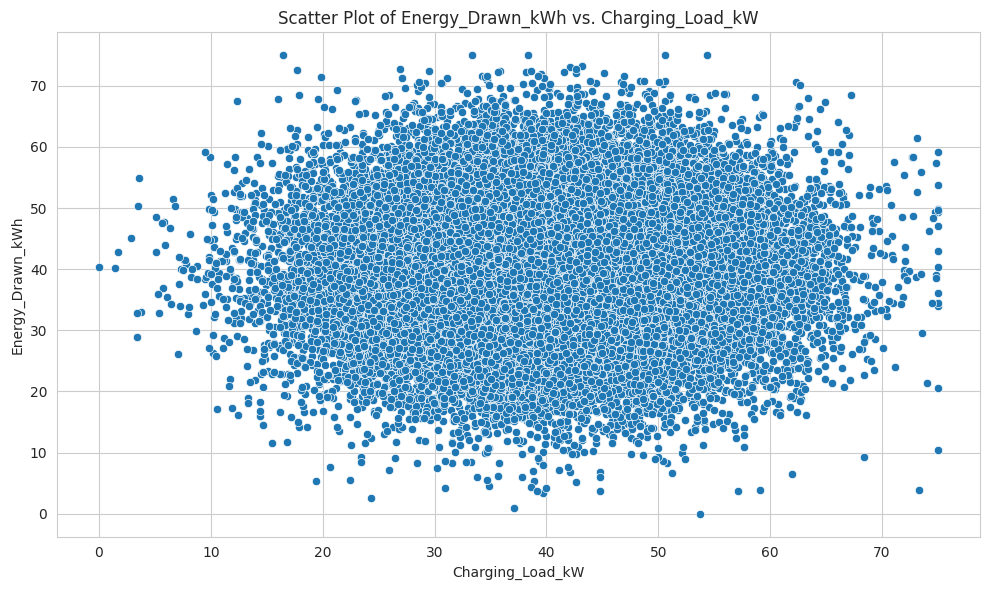

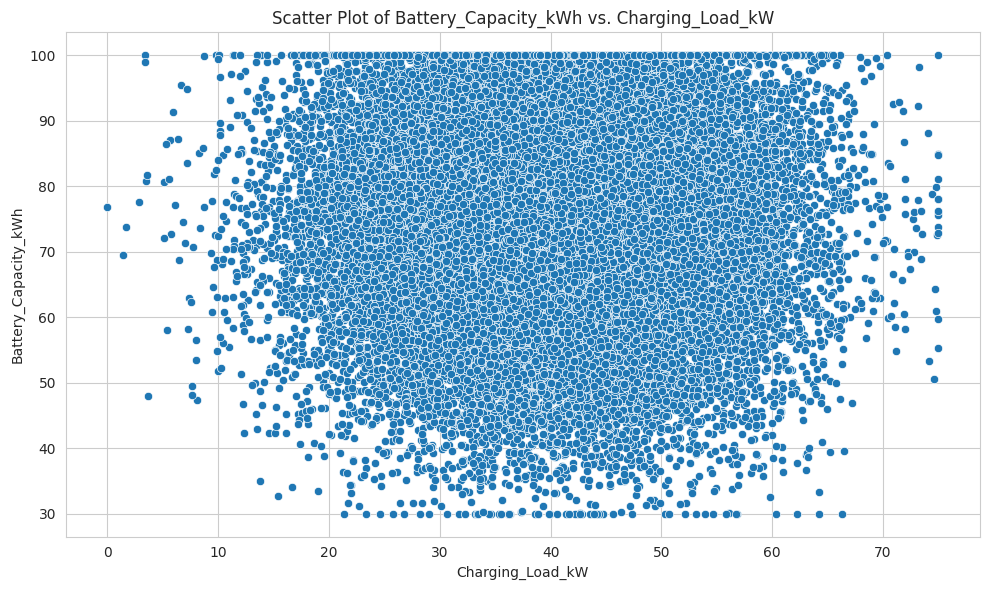

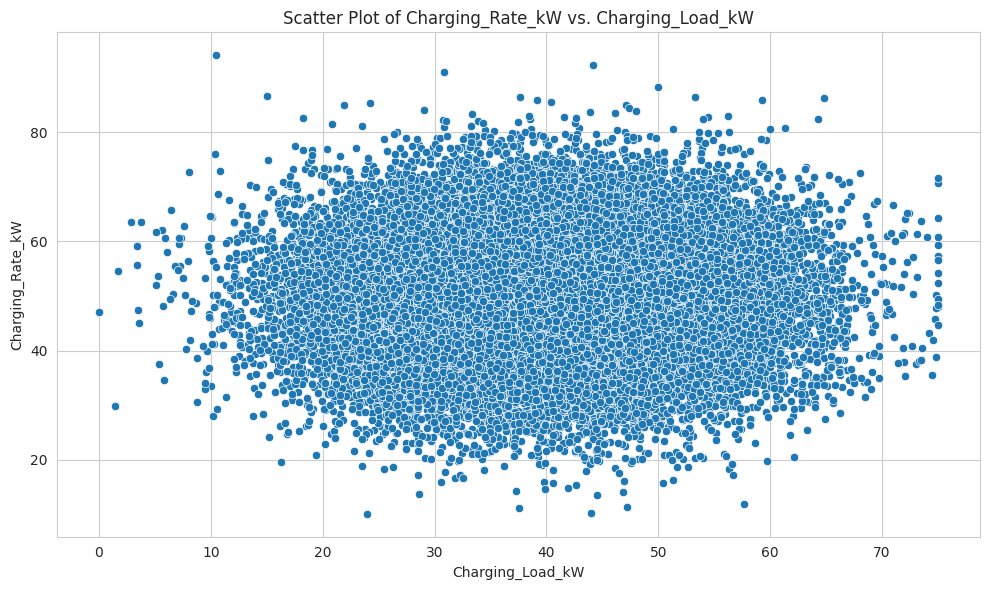

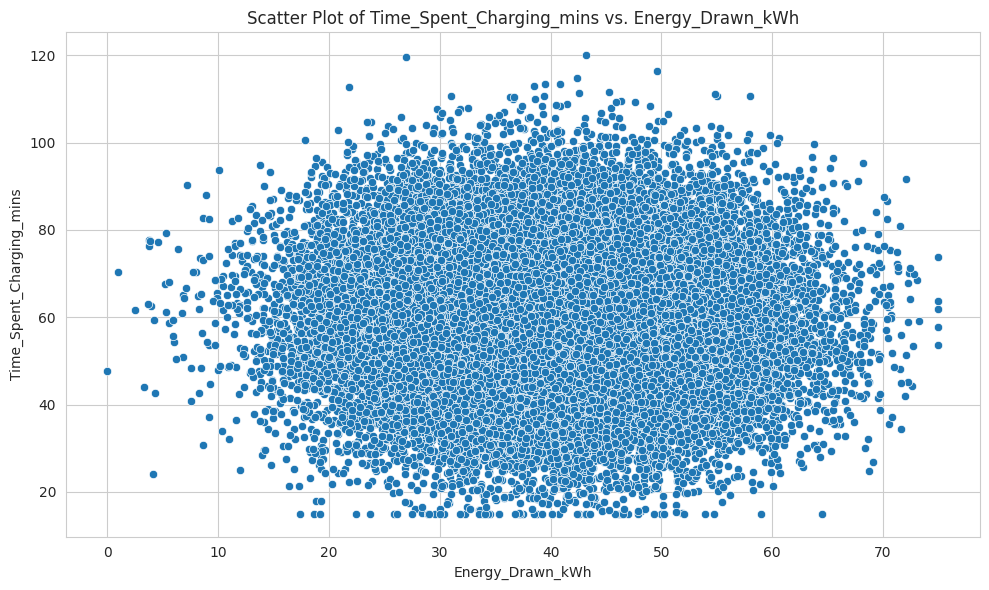

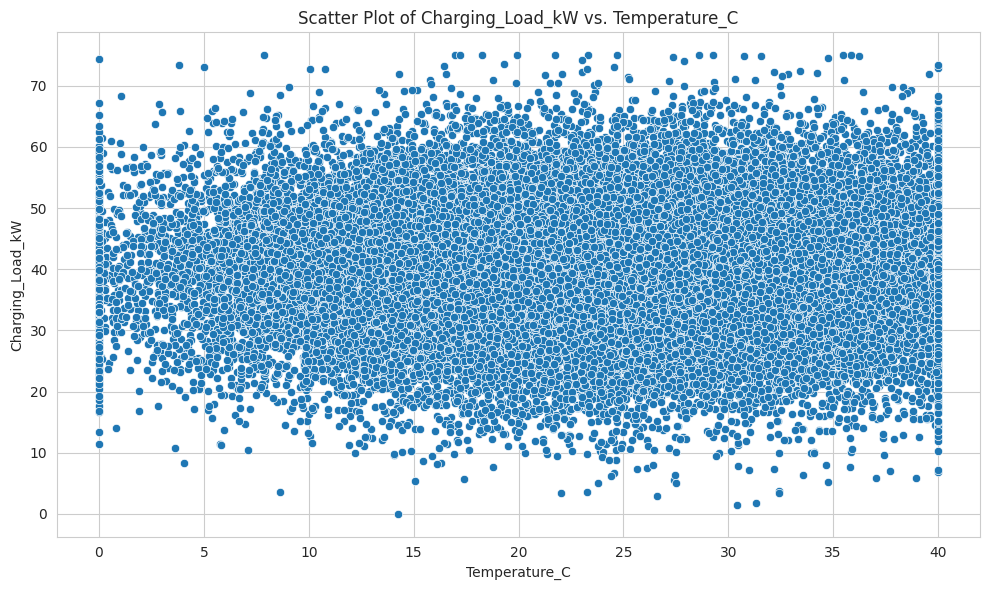

In [ ]:
print("Generating scatter plots for numerical variable pairs...")

# Define the pairs of numerical variables for scatter plots
scatter_plots_pairs = [
    ('Charging_Load_kW', 'Energy_Drawn_kWh'),
    ('Charging_Load_kW', 'Battery_Capacity_kWh'),
    ('Charging_Load_kW', 'Charging_Rate_kW'),
    ('Energy_Drawn_kWh', 'Time_Spent_Charging_mins'),
    ('Temperature_C', 'Charging_Load_kW')
]

for x_col, y_col in scatter_plots_pairs:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_cleaned, x=x_col, y=y_col)
    plt.title(f'Scatter Plot of {y_col} vs. {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

Generating box plots for numerical vs. categorical variables...


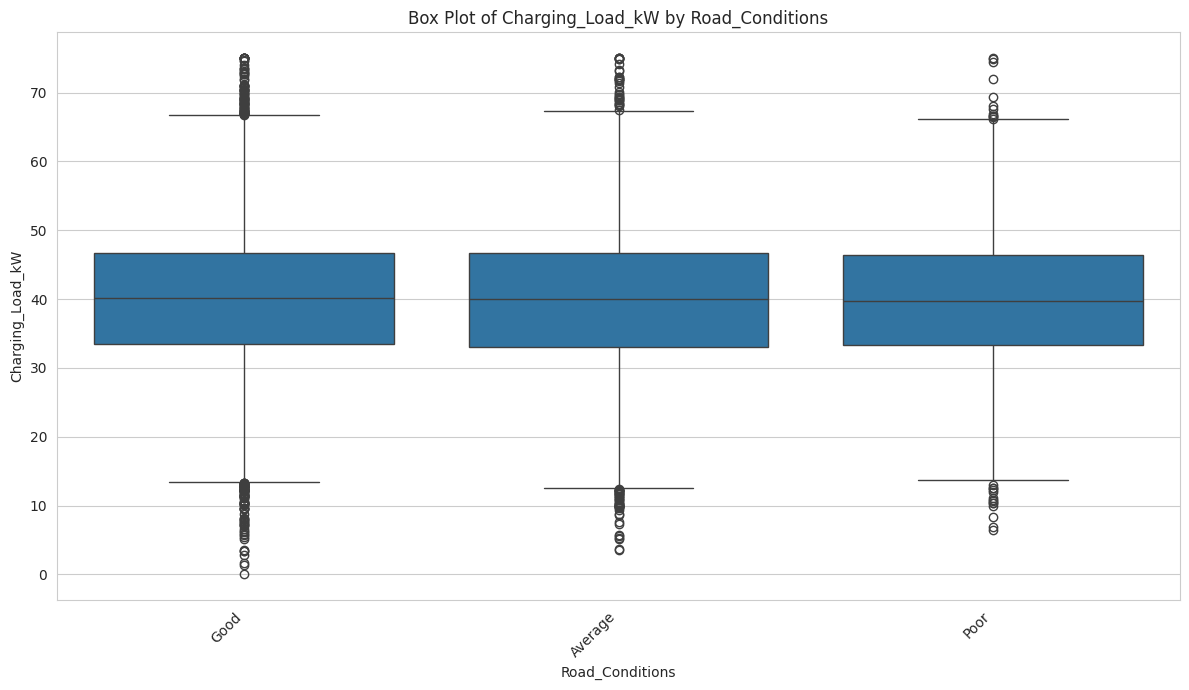

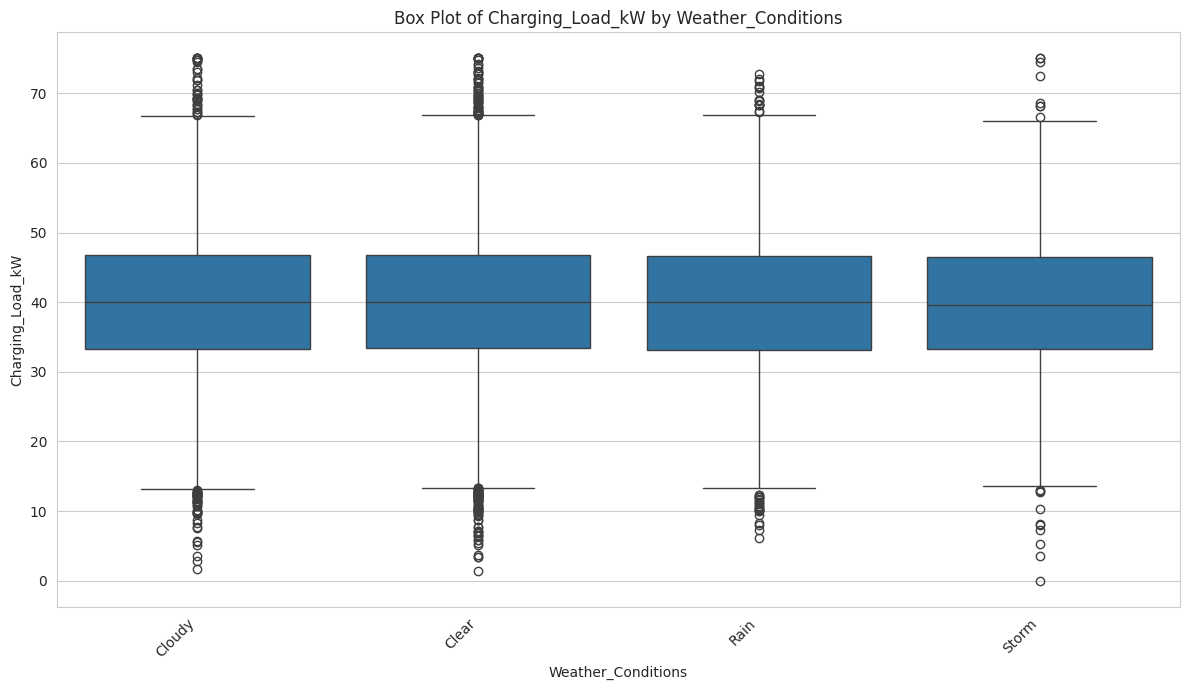

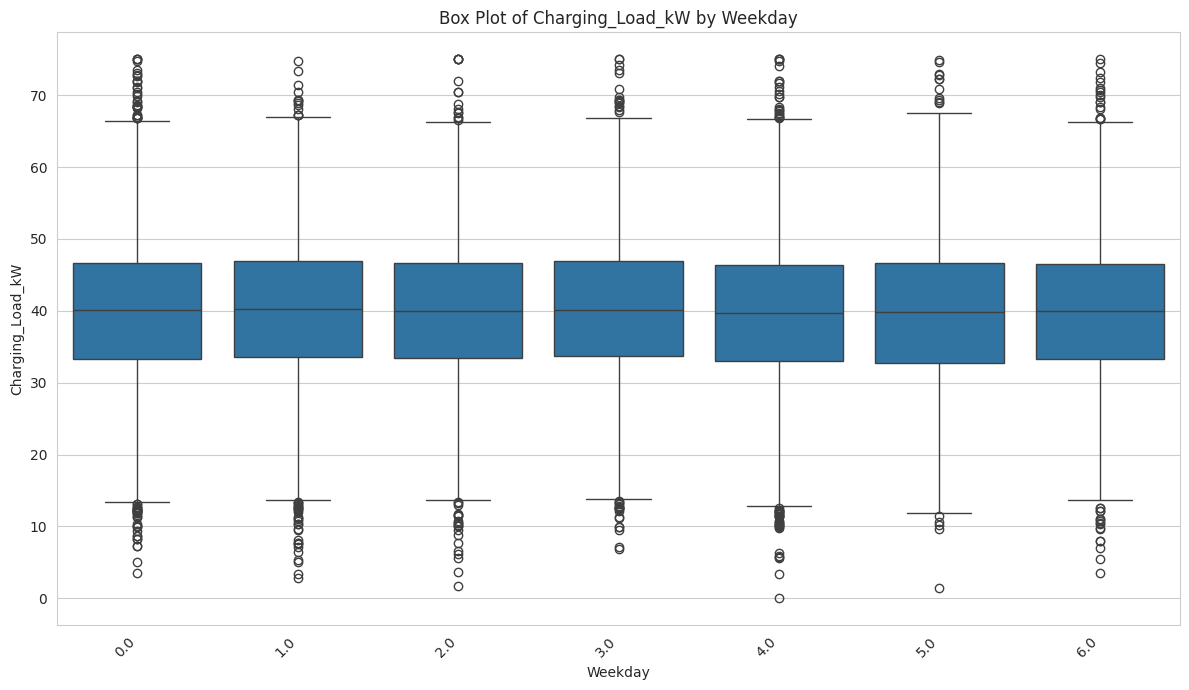

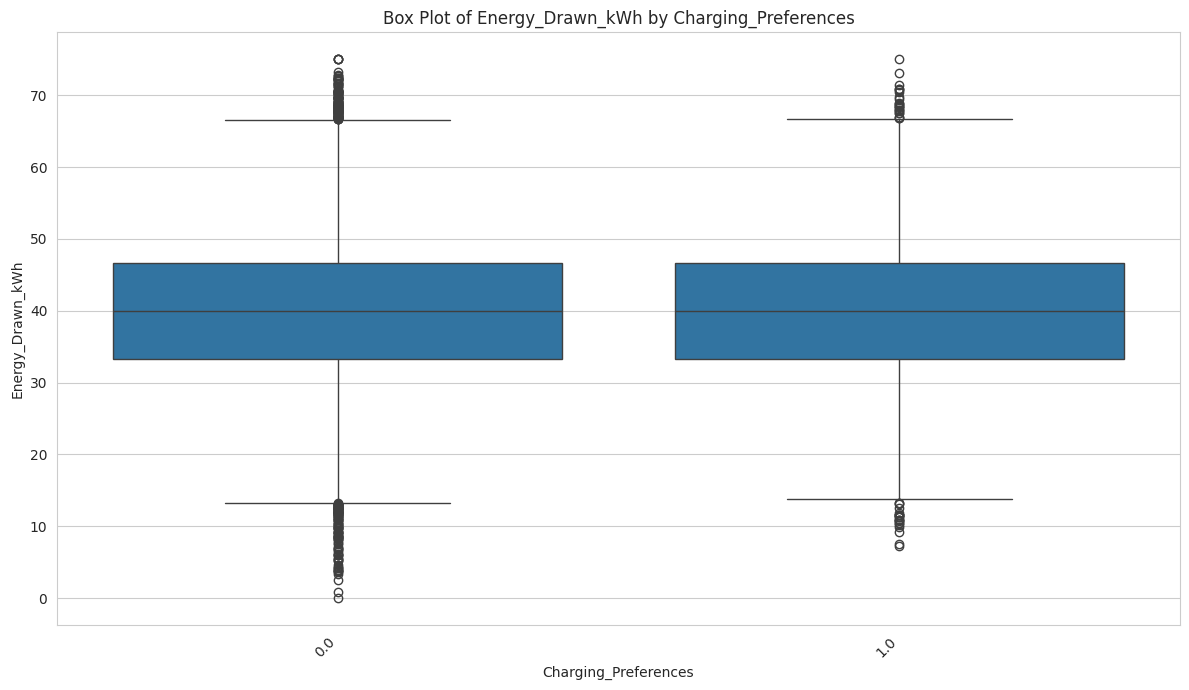

In [ ]:
print("Generating box plots for numerical vs. categorical variables...")

# Define the pairs of numerical and categorical variables for box plots
box_plots_pairs = [
    ('Charging_Load_kW', 'Road_Conditions'),
    ('Charging_Load_kW', 'Weather_Conditions'),
    ('Charging_Load_kW', 'Weekday'),
    ('Energy_Drawn_kWh', 'Charging_Preferences')
]

for y_col, x_col in box_plots_pairs:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_cleaned, x=x_col, y=y_col)
    plt.title(f'Box Plot of {y_col} by {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Calculating the Pearson correlation matrix for numerical columns...
Generating a heatmap visualization of the correlation matrix...


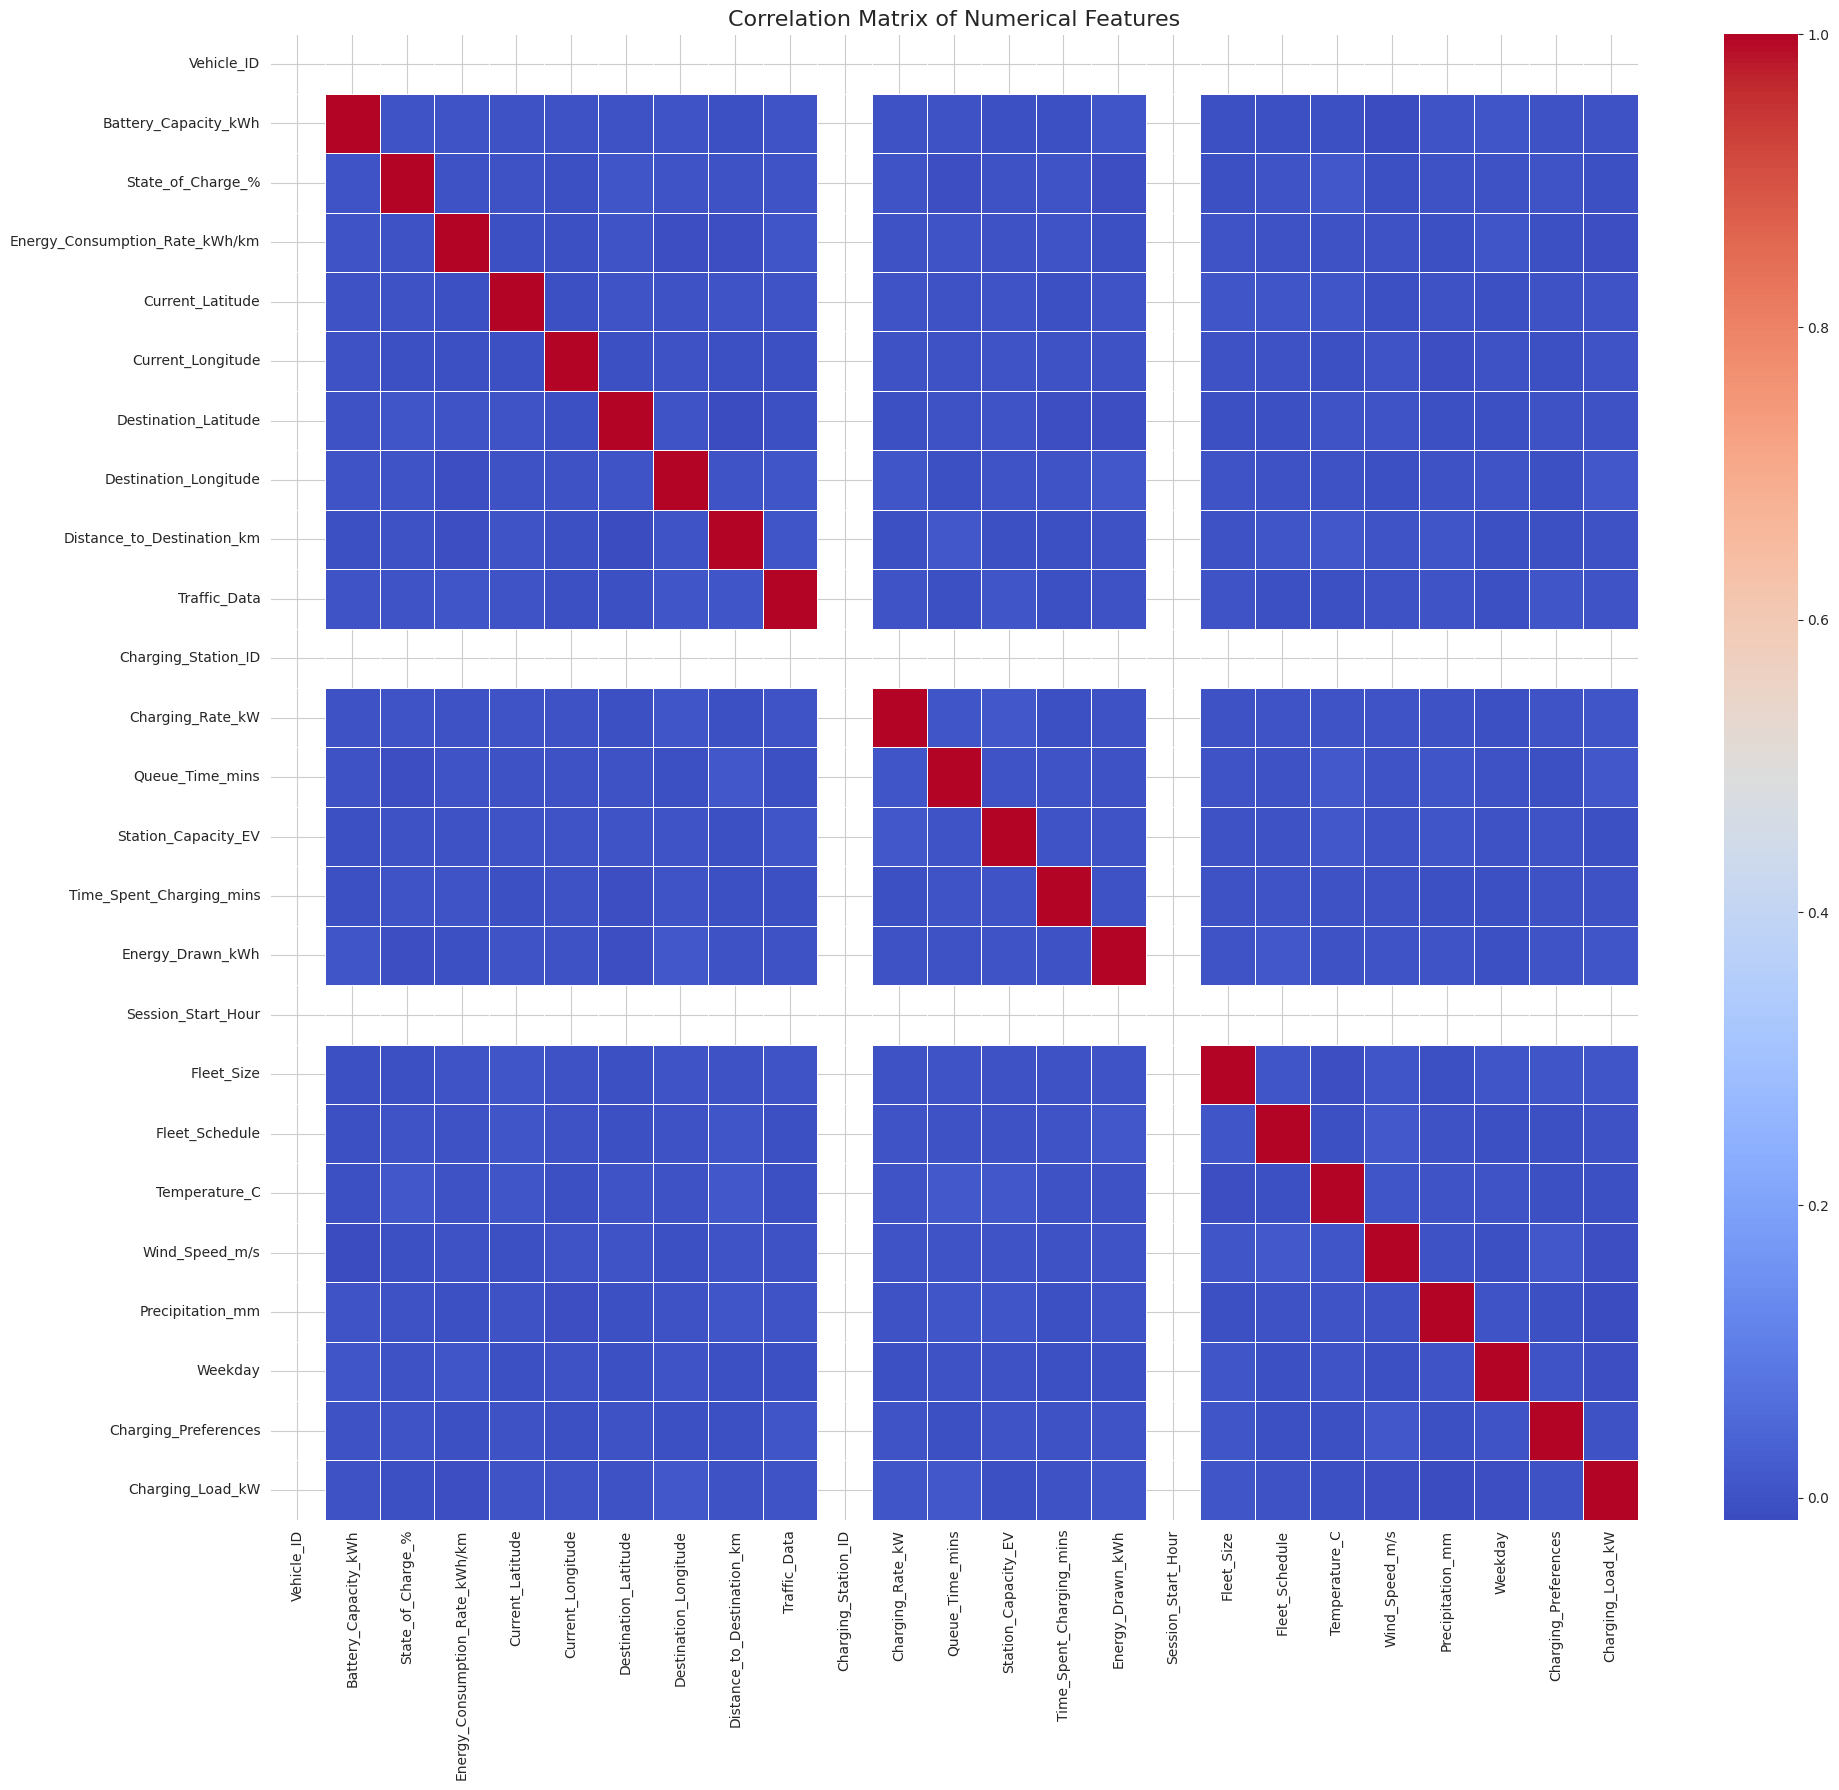

In [ ]:
print("Calculating the Pearson correlation matrix for numerical columns...")
# Calculate the correlation matrix for numerical columns
# Filter only numerical columns from df_cleaned
numerical_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr(method='pearson')

print("Generating a heatmap visualization of the correlation matrix...")
# Create a heatmap visualization of the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Generating time series plot for Charging Load Over Time...


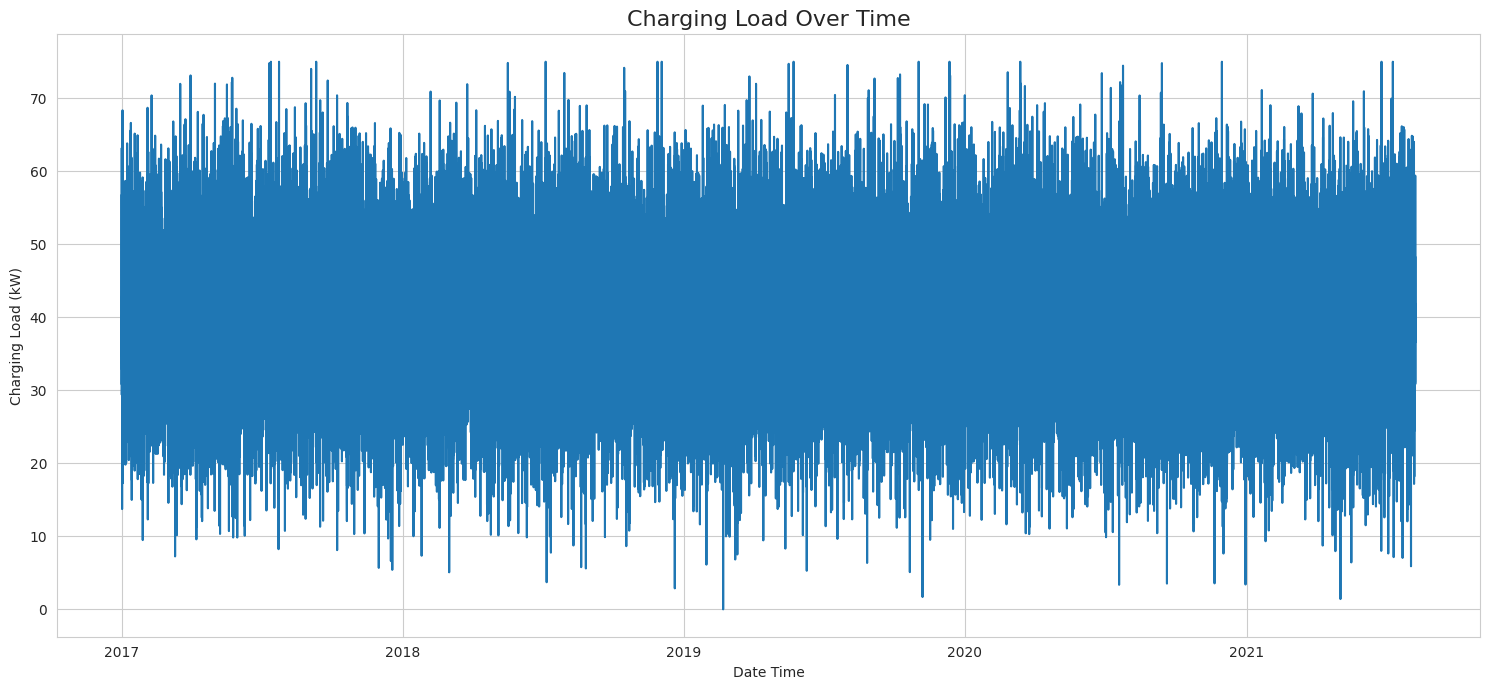

In [ ]:
print("Generating time series plot for Charging Load Over Time...")
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_cleaned, x='Date_Time', y='Charging_Load_kW')
plt.title('Charging Load Over Time', fontsize=16)
plt.xlabel('Date Time')
plt.ylabel('Charging Load (kW)')
plt.tight_layout()
plt.show()

Generating scatter plot with regression line for Charging Load vs. Temperature...


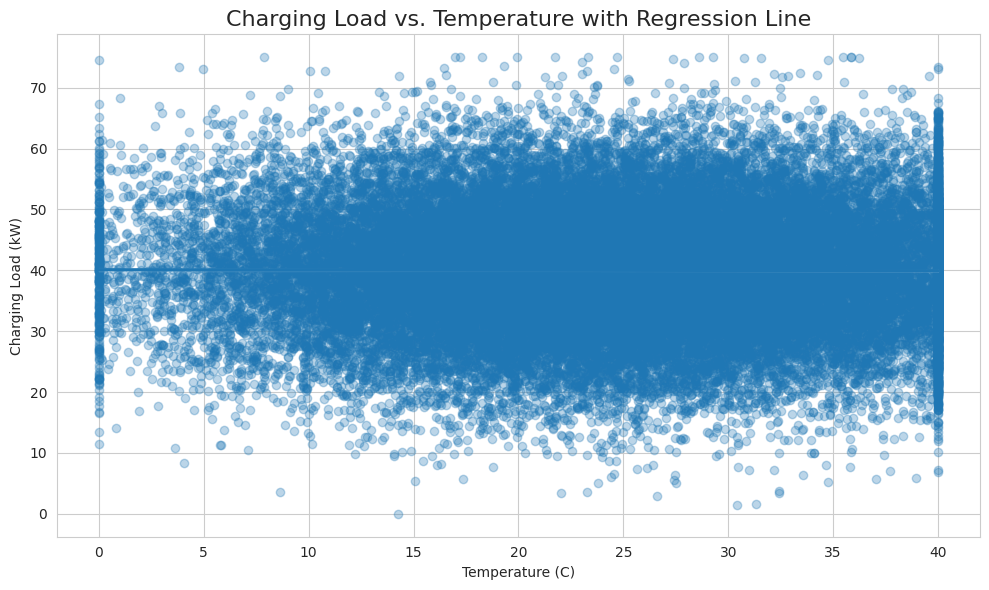

In [ ]:
print("Generating scatter plot with regression line for Charging Load vs. Temperature...")
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cleaned, x='Temperature_C', y='Charging_Load_kW', scatter_kws={'alpha':0.3})
plt.title('Charging Load vs. Temperature with Regression Line', fontsize=16)
plt.xlabel('Temperature (C)')
plt.ylabel('Charging Load (kW)')
plt.tight_layout()
plt.show()

Generating box plot for Charging Load Distribution by Weather Condition...


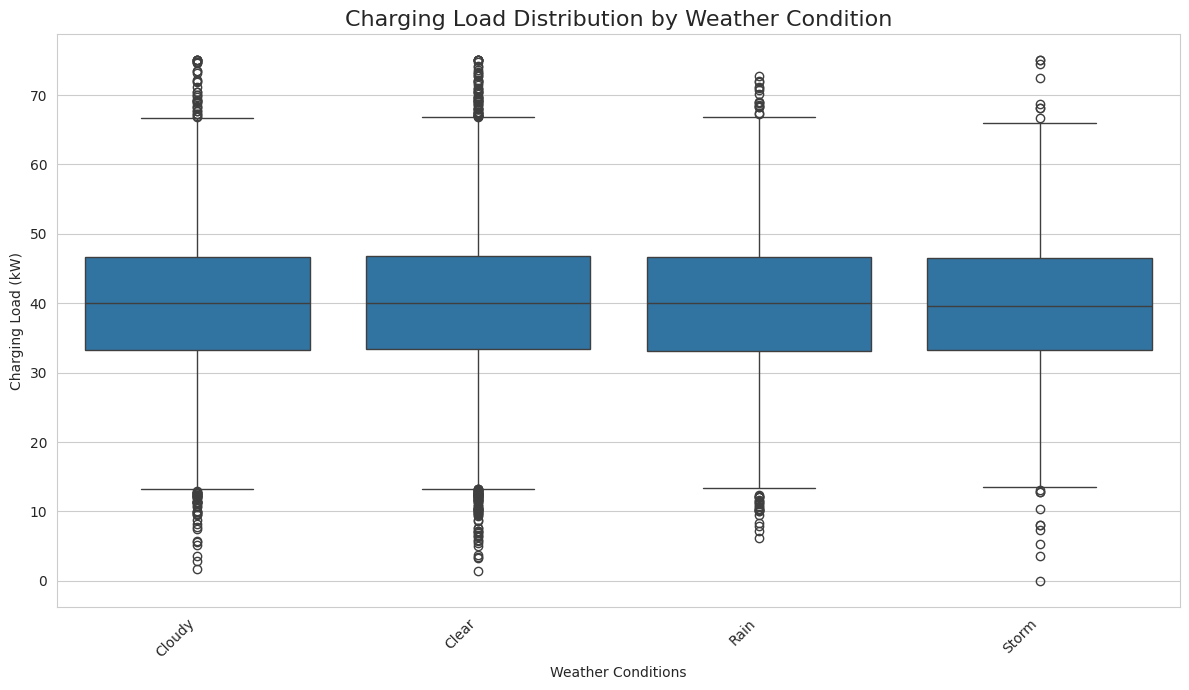

In [ ]:
print("Generating box plot for Charging Load Distribution by Weather Condition...")
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_cleaned, x='Weather_Conditions', y='Charging_Load_kW')
plt.title('Charging Load Distribution by Weather Condition', fontsize=16)
plt.xlabel('Weather Conditions')
plt.ylabel('Charging Load (kW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Select all numerical columns from the df_cleaned DataFrame
numerical_cols_pca = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 2. Exclude the columns 'Vehicle_ID', 'Session_Start_Hour', and 'Destination_Longitude'
exclude_cols_pca = ['Vehicle_ID', 'Session_Start_Hour', 'Destination_Longitude']
numerical_cols_pca = [col for col in numerical_cols_pca if col not in exclude_cols_pca]

# Create a DataFrame with only the selected numerical features
df_pca = df_cleaned[numerical_cols_pca]

# 3. Instantiate a StandardScaler object
scaler = StandardScaler()

# 4. Fit the scaler to the selected numerical features and transform them
scaled_features = scaler.fit_transform(df_pca)

# Convert the scaled features back to a DataFrame for easier handling
scaled_features_df = pd.DataFrame(scaled_features, columns=numerical_cols_pca, index=df_pca.index)

print("Selected numerical columns for PCA:", numerical_cols_pca)
print("Shape of original PCA DataFrame:", df_pca.shape)
print("Shape of scaled features DataFrame:", scaled_features_df.shape)
print("First 5 rows of scaled features:")
print(scaled_features_df.head())

Selected numerical columns for PCA: ['Battery_Capacity_kWh', 'State_of_Charge_%', 'Energy_Consumption_Rate_kWh/km', 'Current_Latitude', 'Current_Longitude', 'Destination_Latitude', 'Distance_to_Destination_km', 'Traffic_Data', 'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins', 'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C', 'Wind_Speed_m/s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences', 'Charging_Load_kW']
Shape of original PCA DataFrame: (40314, 22)
Shape of scaled features DataFrame: (40314, 22)
First 5 rows of scaled features:
   Battery_Capacity_kWh  State_of_Charge_%  Energy_Consumption_Rate_kWh/km  \
0             -0.557760           1.364189                       -0.282646   
1              0.556646           1.937093                       -0.695349   
2              0.513172          -0.876502                       -0.924381   
3              1.448675          -0.341135                  

In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA without specifying the number of components
pca = PCA()

# Fit PCA to the scaled numerical data
pca.fit(scaled_features_df)

# Calculate the explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio for each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

Explained variance ratio for each principal component:
Principal Component 1: 0.0497
Principal Component 2: 0.0493
Principal Component 3: 0.0489
Principal Component 4: 0.0488
Principal Component 5: 0.0487
Principal Component 6: 0.0484
Principal Component 7: 0.0482
Principal Component 8: 0.0480
Principal Component 9: 0.0479
Principal Component 10: 0.0477
Principal Component 11: 0.0477
Principal Component 12: 0.0476
Principal Component 13: 0.0473
Principal Component 14: 0.0471
Principal Component 15: 0.0470
Principal Component 16: 0.0467
Principal Component 17: 0.0465
Principal Component 18: 0.0464
Principal Component 19: 0.0462
Principal Component 20: 0.0460
Principal Component 21: 0.0460
Principal Component 22: 0.0000


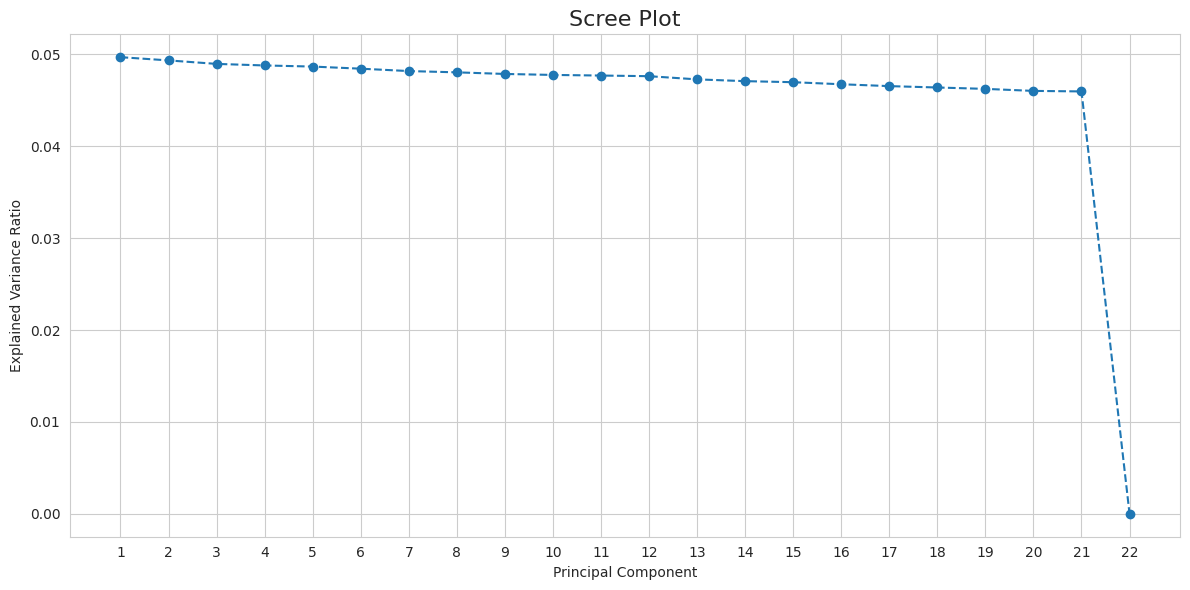

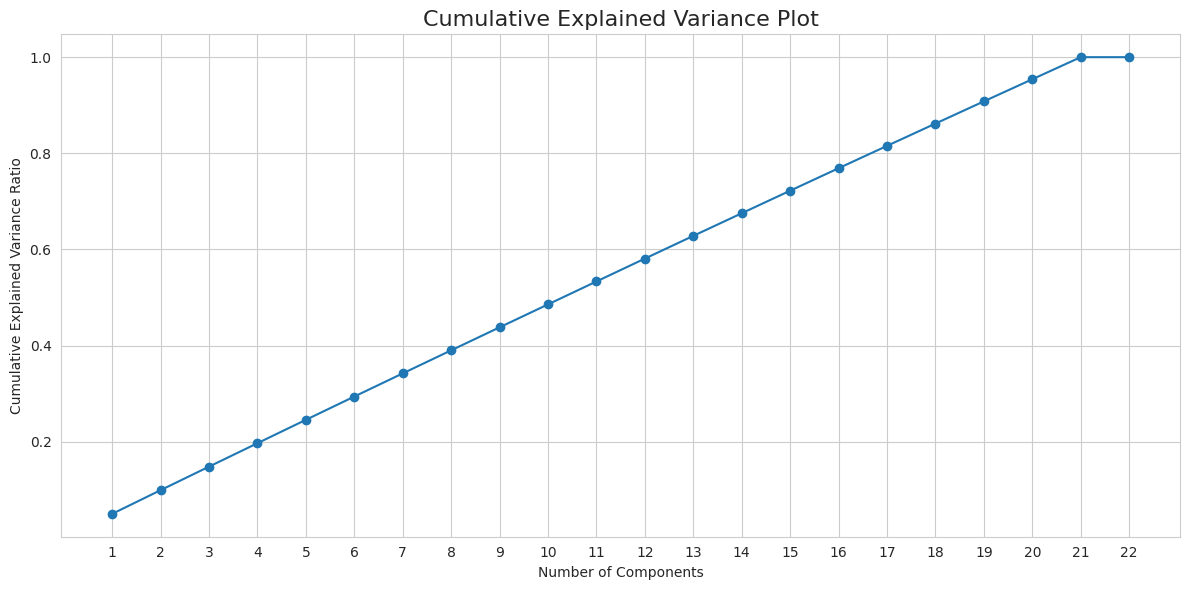

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(explained_variance_ratio)

# 1. Create a scree plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot', fontsize=16)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.tight_layout()
plt.show()

# 2. Create a cumulative explained variance plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance Plot', fontsize=16)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(range(1, len(cum_explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

Transforming data using PCA and generating a scatter plot of the first two principal components...


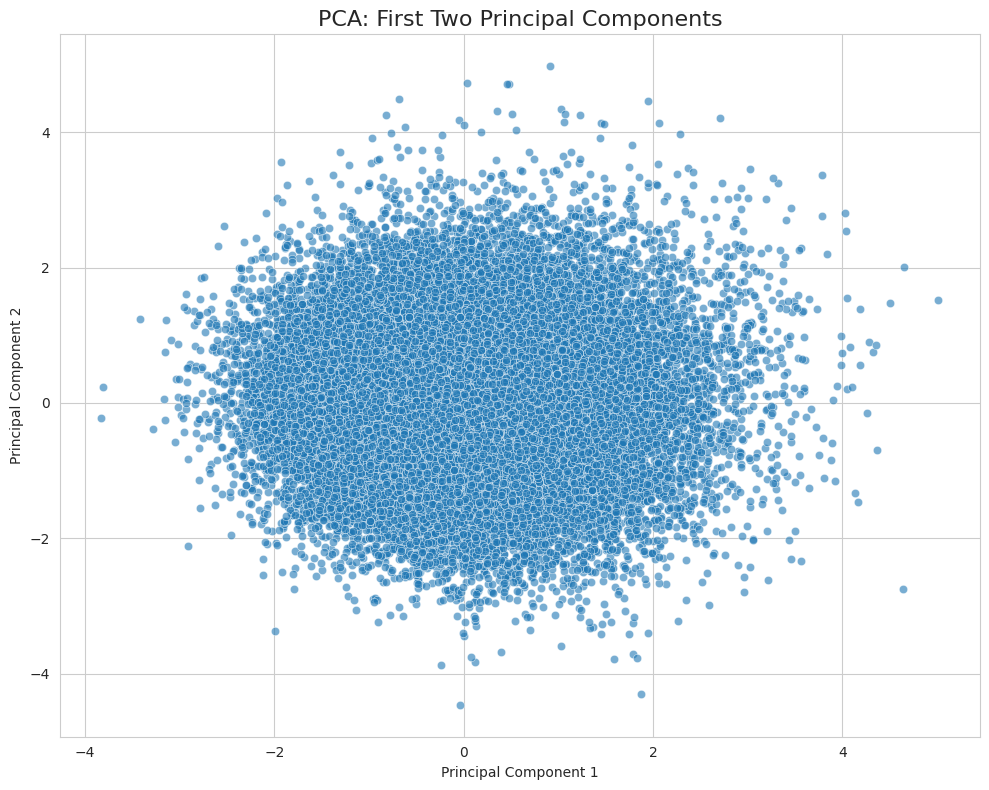

In [ ]:
print("Transforming data using PCA and generating a scatter plot of the first two principal components...")

# Transform the scaled_features_df using the fitted PCA model
principal_components = pca.transform(scaled_features_df)

# Create a DataFrame from the transformed components
pc_df = pd.DataFrame(data = principal_components,
                     columns = [f'Principal Component {i+1}' for i in range(principal_components.shape[1])],
                     index=scaled_features_df.index)

# Create a scatter plot of the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pc_df, alpha=0.6)
plt.title('PCA: First Two Principal Components', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import random

# Set a global seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# 1. Define the target variable 'y'
y = df_cleaned['Charging_Load_kW']

# 2. Define the features 'X' using the first 17 principal components
X = pc_df.iloc[:, :17]

# 3. Split the data using the fixed seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Data split using random_state={RANDOM_SEED}")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Data split using random_state=42
Shape of X_train: (32251, 17)
Shape of X_test: (8063, 17)


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# 2. Train the model using the training data
# Ensure cell 66b6c06c is executed first to define X_train and y_train
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {linear_reg_model.coef_}")
print(f"Model intercept: {linear_reg_model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [ 2.50550424 -3.62735169 -3.0950636   3.77725763 -0.3760241  -0.96661929
 -1.02986167  1.75830104 -0.0635878  -1.11054761  0.32626107  0.26011363
  0.77138918 -2.15360386 -2.11031302  1.21778162 -0.58217538]
Model intercept: 40.03181314913143


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Linear Regression Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 6.0123
Mean Absolute Error (MAE): 4.7832
R-squared (R2): 0.6329


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# KNN doesn't have a random_state, but we ensure parameters are fixed
knn_reg_model = KNeighborsRegressor(n_neighbors=5)
knn_reg_model.fit(X_train, y_train)

print("K-Nearest Neighbors Regressor model trained.")

K-Nearest Neighbors Regressor model trained.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_knn = knn_reg_model.predict(X_test)

# Evaluate the model
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_knn:.4f}")
print(f"R-squared (R2): {r2_knn:.4f}")

K-Nearest Neighbors Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 6.7058
Mean Absolute Error (MAE): 5.2913
R-squared (R2): 0.5433


In [ ]:
from sklearn.svm import SVR

# SVR is deterministic for a fixed dataset, but we'll re-train to be sure
svr_model = SVR()
svr_model.fit(X_train, y_train)

print("Support Vector Regressor model trained.")

Support Vector Regressor model trained.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.4f}")
print(f"R-squared (R2): {r2_svr:.4f}")

Support Vector Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 4.7911
Mean Absolute Error (MAE): 3.6908
R-squared (R2): 0.7669


In [ ]:
from xgboost import XGBRegressor

# Adding random_state to XGBoost
xgb_reg_model = XGBRegressor(random_state=RANDOM_SEED)
xgb_reg_model.fit(X_train, y_train)

print(f"XGBoost Regressor model trained with random_state={RANDOM_SEED}")

XGBoost Regressor model trained with random_state=42


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_xgb = xgb_reg_model.predict(X_test)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

XGBoost Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 5.3062
Mean Absolute Error (MAE): 4.1818
R-squared (R2): 0.7141


In [ ]:
print("Reshaping X_train and X_test for LSTM input...")

# Reshape X_train from (samples, features) to (samples, 1, features)
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])

# Reshape X_test from (samples, features) to (samples, 1, features)
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"New shape of X_train_lstm: {X_train_lstm.shape}")
print(f"New shape of X_test_lstm: {X_test_lstm.shape}")

Reshaping X_train and X_test for LSTM input...
New shape of X_train_lstm: (32251, 1, 17)
New shape of X_test_lstm: (8063, 1, 17)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("Initializing and training LSTM Regressor model...")

model = Sequential()
model.add(tf.keras.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(LSTM(20, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train,
    epochs=500,
    batch_size=64,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("Optimized LSTM Regressor model training completed.")

Initializing and training LSTM Regressor model...
Epoch 1/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 396.0182 - val_loss: 47.9627
Epoch 2/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 110.6330 - val_loss: 34.1175
Epoch 3/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 88.5826 - val_loss: 31.1406
Epoch 4/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 78.6197 - val_loss: 29.6905
Epoch 5/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 75.1622 - val_loss: 25.4586
Epoch 6/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 70.3884 - val_loss: 25.2105
Epoch 7/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 66.5751 - val_loss: 25.9596
Epoch 8/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 62.9505 - val_loss: 23.2048
Epoch 9/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 57.2822 - val_loss: 22.2612
Epoch 10/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 51.6998 - val_loss: 22.3933
Epoch 11/500
404/404 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

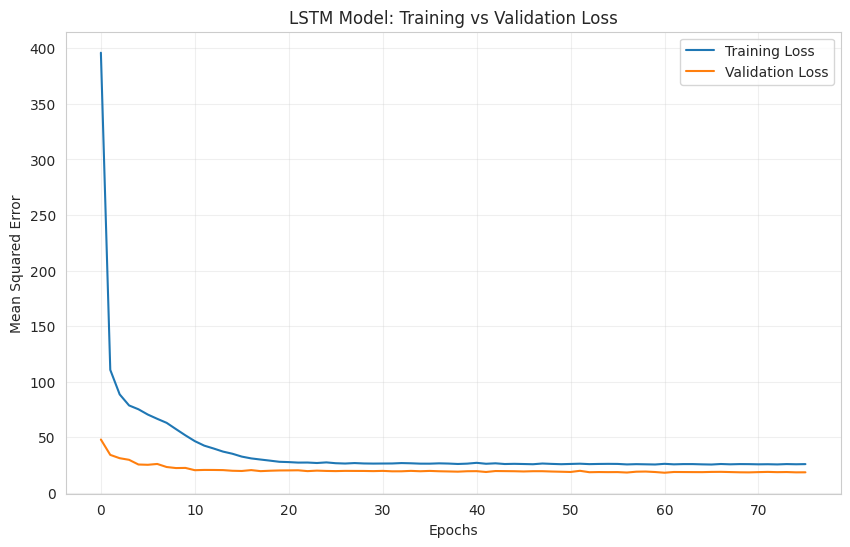

In [ ]:
import matplotlib.pyplot as plt

# Visualize LSTM training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set using LSTM
y_pred_lstm_final = model.predict(X_test_lstm)

# Evaluate the model
rmse_lstm_final = np.sqrt(mean_squared_error(y_test, y_pred_lstm_final))
mae_lstm_final = mean_absolute_error(y_test, y_pred_lstm_final)
r2_lstm_final = r2_score(y_test, y_pred_lstm_final)

print("LSTM Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm_final:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm_final:.4f}")
print(f"R-squared (R2): {r2_lstm_final:.4f}")

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 4.1560
Mean Absolute Error (MAE): 3.1181
R-squared (R2): 0.8246


### **7. Transformer Model for Regression**

We will now implement a Transformer-based architecture. Transformers use self-attention mechanisms to weigh the significance of different parts of the input data. For this tabular regression task, we treat our 17 principal components as a single sequence of features.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Resetting the global seed before building the Transformer
tf.random.set_seed(RANDOM_SEED)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_transformer_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    x = layers.GlobalAveragePooling1D(data_format='channels_last')(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation='relu')(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
transformer_model = build_transformer_model(
    input_shape, head_size=64, num_heads=4, ff_dim=64,
    num_transformer_blocks=2, mlp_units=[64], dropout=0.1, mlp_dropout=0.1
)

transformer_model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))
transformer_model.summary()
print('\nTransformer model built with seeded initialization.')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 17)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 17)     │         34 │ input_layer_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 17)     │     18,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 17)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 17)     │          0 │ dropout_2[0][0],  │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 17)     │         34 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 64)     │      1,152 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 64)     │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 17)     │      1,105 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 17)     │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 17)     │         34 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 17)     │     18,193 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1, 17)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1, 17)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 17)     │         34 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 64)     │      1,152 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1, 64)     │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 17)     │      1,105 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 17)     │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 42,253 (165.05 KB)

 Trainable params: 42,253 (165.05 KB)

 Non-trainable params: 0 (0.00 B)


Transformer model built with seeded initialization.


In [ ]:
callbacks = [EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')]

print("Training Transformer Model...")
history_transformer = transformer_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


print("Transformer Model Training Completed...")

Training Transformer Model...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


404/404 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - loss: 152.8956 - val_loss: 37.4343
Epoch 2/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 47.1169 - val_loss: 32.8893
Epoch 3/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 43.2162 - val_loss: 31.3460
Epoch 4/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 40.5441 - val_loss: 29.9210
Epoch 5/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 38.4468 - val_loss: 26.5930
Epoch 6/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 35.5184 - val_loss: 27.0741
Epoch 7/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 33.8590 - val_loss: 23.7269
Epoch 8/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 32.6514 - val_loss: 21.7177
Epoch 9/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 31.1217 - val_loss: 20.9295
Epoch 10/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 30.4037 - val_loss: 20.2664
Epoch 11/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 29.8540 - val_loss: 20.3160
Epoch 12/200
404/404 ━━━━━━━

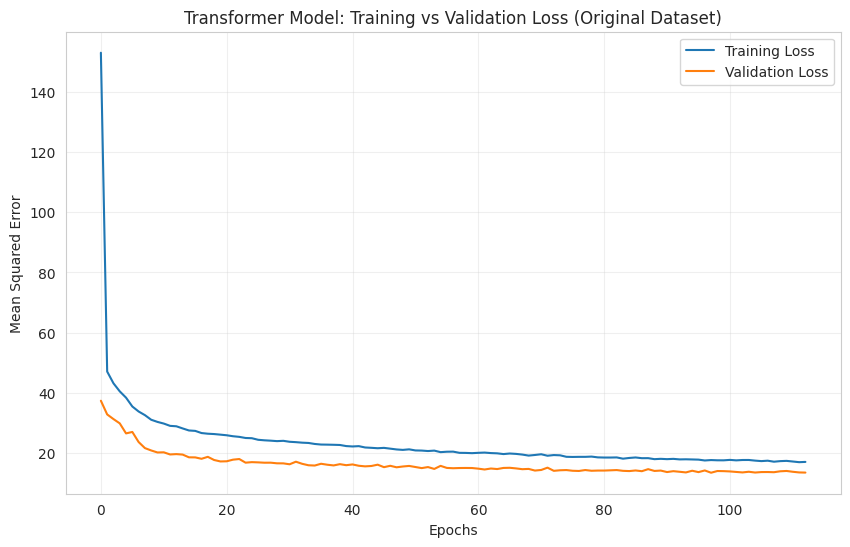

In [ ]:
import matplotlib.pyplot as plt

# Visualize Transformer training history (Original Dataset)
plt.figure(figsize=(10, 6))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')
plt.title('Transformer Model: Training vs Validation Loss (Original Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions
y_pred_trans = transformer_model.predict(X_test_lstm)

# Evaluate the model
rmse_trans = np.sqrt(mean_squared_error(y_test, y_pred_trans))
mae_trans = mean_absolute_error(y_test, y_pred_trans)
r2_trans = r2_score(y_test, y_pred_trans)

print("Transformer Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_trans:.4f}")
print(f"Mean Absolute Error (MAE): {mae_trans:.4f}")
print(f"R-squared (R2): {r2_trans:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Transformer Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 3.5116
Mean Absolute Error (MAE): 2.5869
R-squared (R2): 0.8748


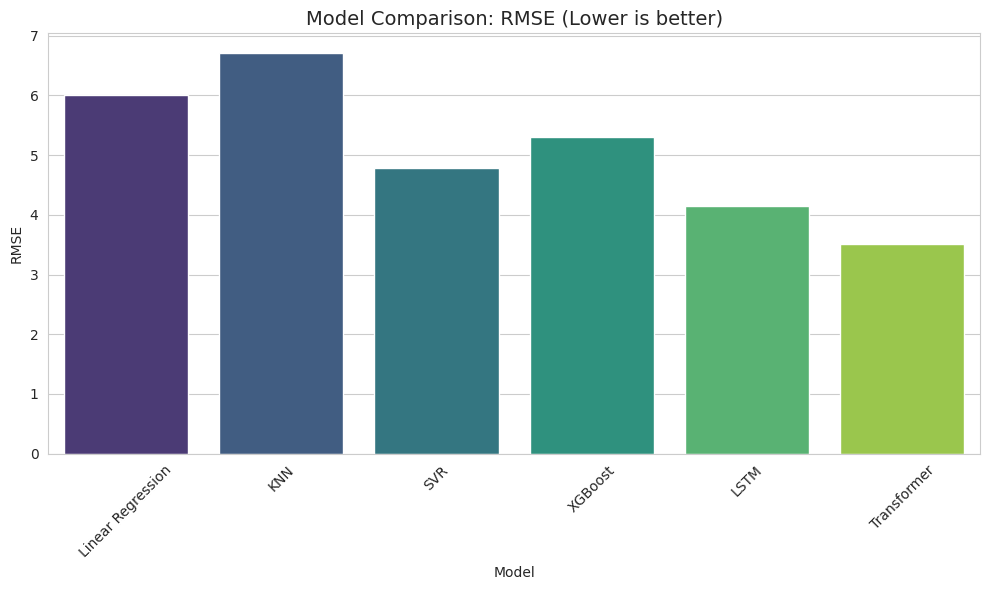

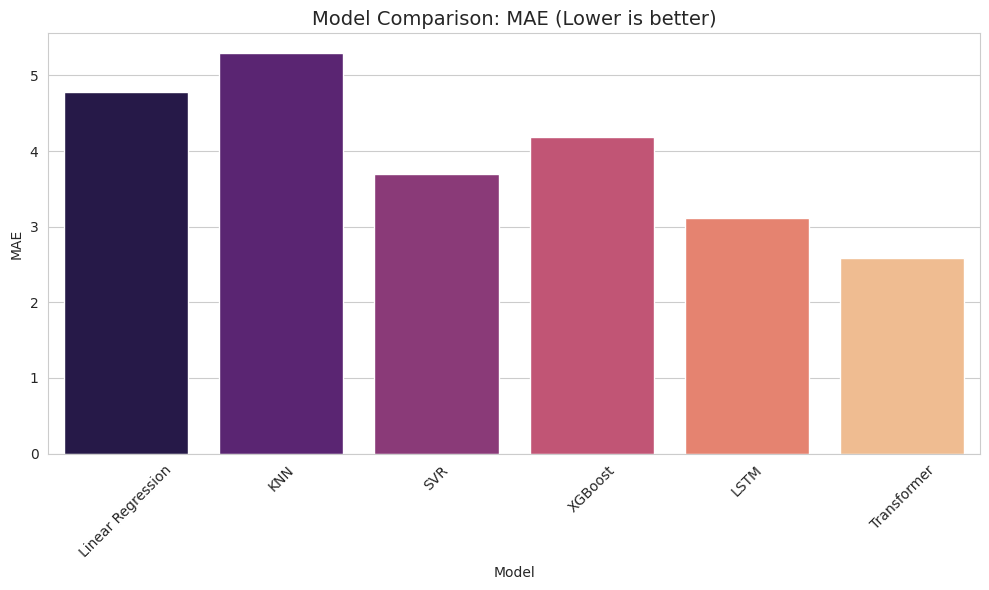

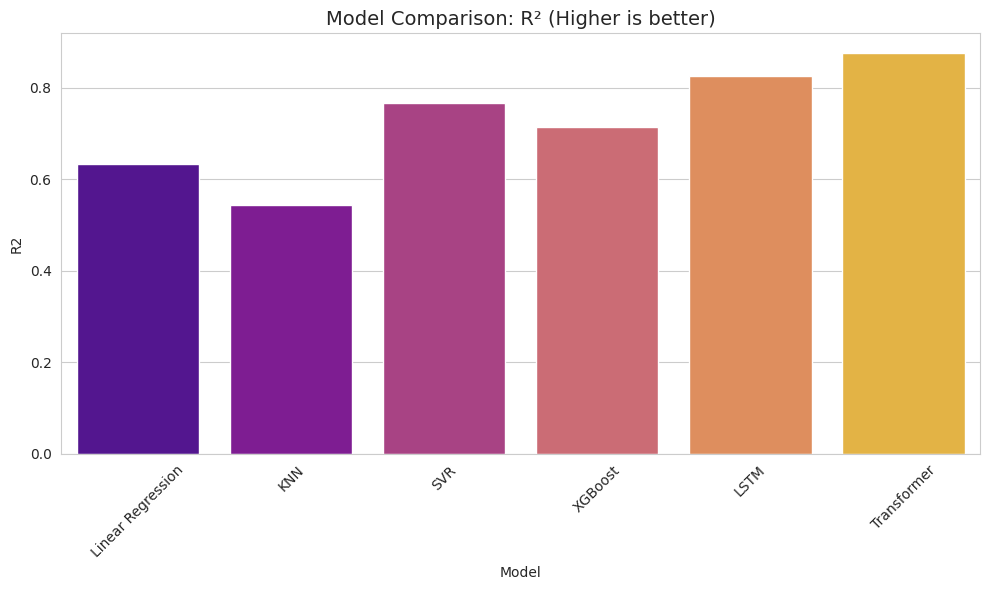

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
models = ['Linear Regression', 'KNN', 'SVR', 'XGBoost', 'LSTM', 'Transformer']
rmse_vals = [rmse, rmse_knn, rmse_svr, rmse_xgb, rmse_lstm_final, rmse_trans]
mae_vals = [mae, mae_knn, mae_svr, mae_xgb, mae_lstm_final, mae_trans]
r2_vals = [r2, r2_knn, r2_svr, r2_xgb, r2_lstm_final, r2_trans]

metrics_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_vals,
    'MAE': mae_vals,
    'R2': r2_vals
})

sns.set_style("whitegrid")

# 1. Plot RMSE
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=metrics_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: RMSE (Lower is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Plot MAE
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', data=metrics_df, palette='magma', hue='Model', legend=False)
plt.title('Model Comparison: MAE (Lower is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Plot R2
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=metrics_df, palette='plasma', hue='Model', legend=False)
plt.title('Model Comparison: R² (Higher is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

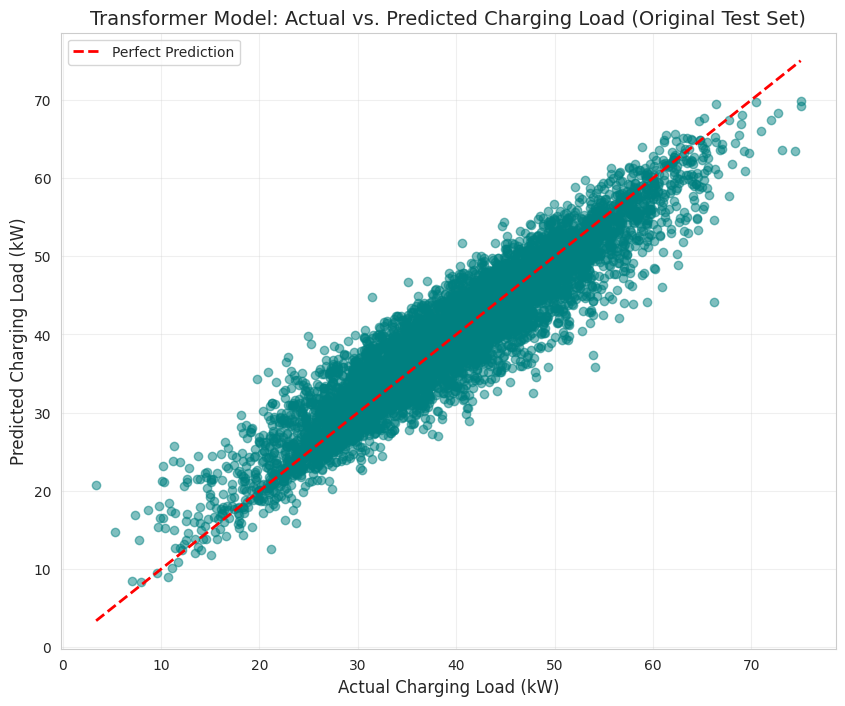

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions for the Transformer model on the original test set
y_pred_trans_flat = y_pred_trans.flatten()

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_trans_flat, alpha=0.5, color='teal')

# Add a 45-degree line for reference (Perfect Prediction)
max_val = max(y_test.max(), y_pred_trans_flat.max())
min_val = min(y_test.min(), y_pred_trans_flat.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Transformer Model: Actual vs. Predicted Charging Load (Original Test Set)', fontsize=14)
plt.xlabel('Actual Charging Load (kW)', fontsize=12)
plt.ylabel('Predicted Charging Load (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **8. Performance Evaluation on Pakistan Synthetic Data**

We will now test our best performing model (the Transformer) on the new dataset: `Pakistan_EV_Charging_Dataset_MonteCarlo.csv`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the Pakistan Synthetic Dataset
pakistan_df = pd.read_csv('/content/Pakistan_EV_Charging_Dataset_MonteCarlo.csv')

### **9. Diagnostic: Comparing Data Distributions**

The evaluation above showed a massive error. Let's compare the distributions of the original training data and the Pakistan synthetic data to identify the mismatch.

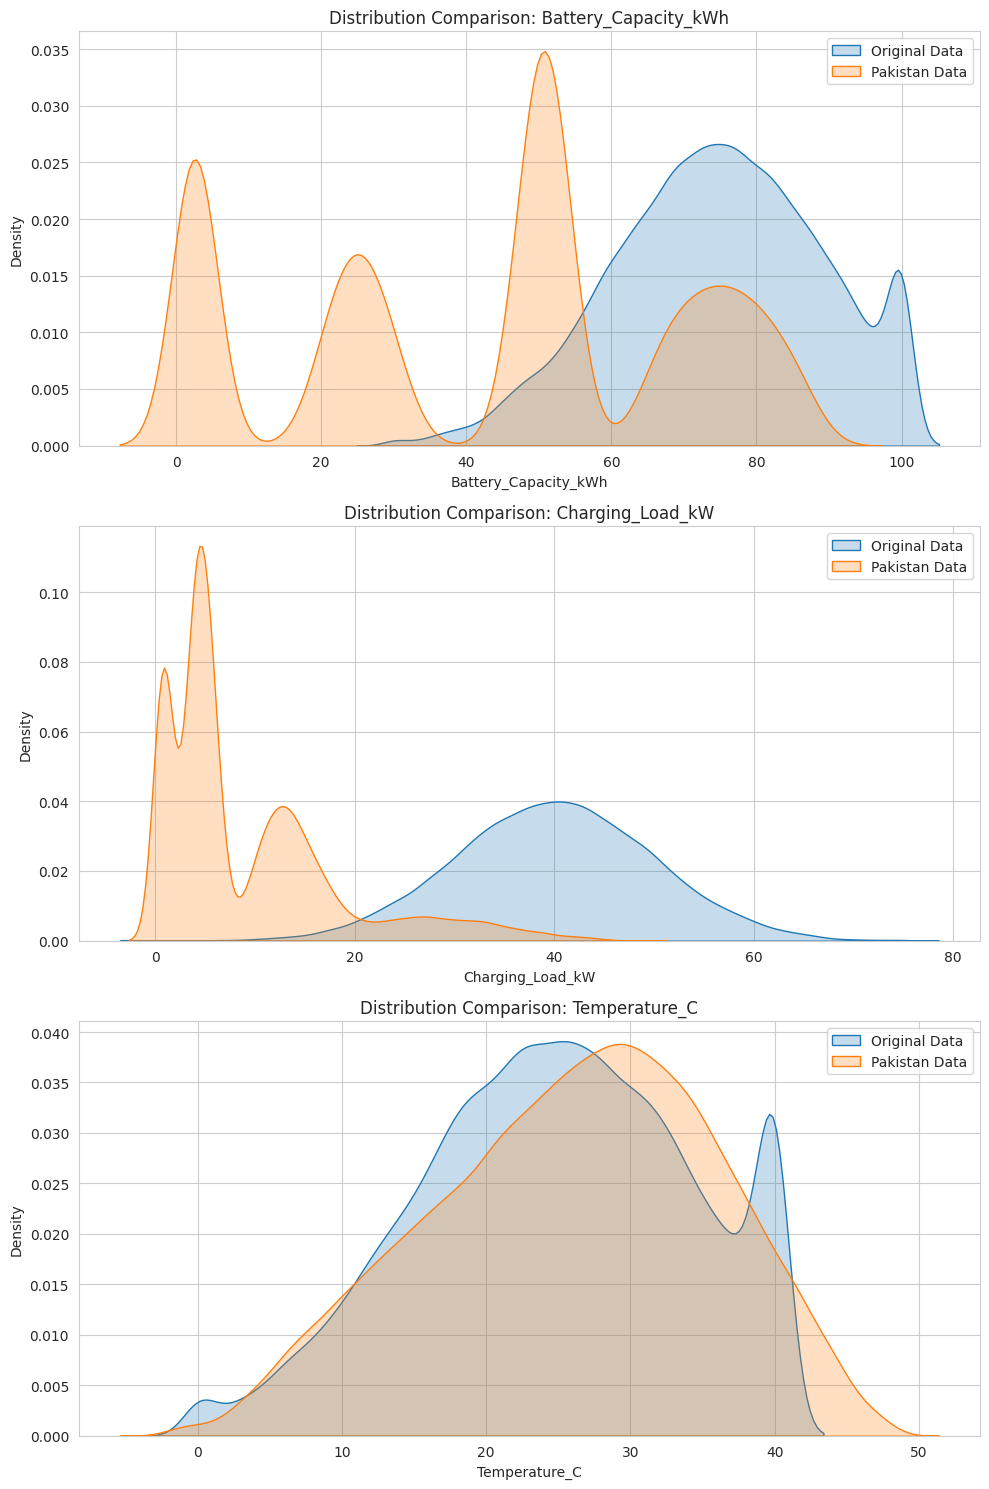

Original Data Stats:


,Battery_Capacity_kWh,Charging_Load_kW,Temperature_C
count,40314.000000,40314.000000,40314.000000
mean,74.746980,39.997896,24.659492
std,14.344163,9.964990,9.413458
min,30.000000,0.000000,0.000000
25%,64.933064,33.300415,18.139524
50%,75.006591,40.015528,24.940763
75%,85.162862,46.710373,31.755475
max,100.000000,75.000000,40.000000



Pakistan Data Stats:


,Battery_Capacity_kWh,Charging_Load_kW,Temperature_C
count,50000.000000,50000.000000,50000.000000
mean,43.009212,9.150581,25.985018
std,26.879599,8.898922,9.872611
min,1.500000,0.400000,-2.000000
25%,22.600000,3.470000,19.000000
50%,49.700000,5.300000,26.800000
75%,67.400000,13.310000,33.400000
max,88.000000,48.300000,48.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to compare
compare_cols = ['Battery_Capacity_kWh', 'Charging_Load_kW', 'Temperature_C']

fig, axes = plt.subplots(len(compare_cols), 1, figsize=(10, 15))

for i, col in enumerate(compare_cols):
    sns.kdeplot(df_cleaned[col], ax=axes[i], label='Original Data', fill=True)
    sns.kdeplot(pakistan_df[col], ax=axes[i], label='Pakistan Data', fill=True)
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Check basic statistics mismatch
print("Original Data Stats:")
display(df_cleaned[compare_cols].describe())

print("\nPakistan Data Stats:")
display(pakistan_df[compare_cols].describe())

### **10. Deeper Investigation: Correlation and Range Analysis**

We need to see if the relationship between features in the Pakistan dataset (generated via Monte Carlo) matches the original data. If the correlations are different, the model's learned weights will not apply.

Correlation with Charging_Load_kW Comparison:


,Pakistan_Corr,Original_Corr
Battery_Capacity_kWh,0.352128,-0.001646
Charging_Load_kW,1.000000,1.000000
Charging_Preferences,-0.002270,-0.002802
Charging_Rate_kW,0.987433,0.006645
Charging_Station_ID,NaN,NaN
Current_Latitude,0.002226,0.001854
Current_Longitude,0.002426,0.002139
Destination_Latitude,0.003721,-0.001693
Distance_to_Destination_km,0.109644,-0.001493
Energy_Consumption_Rate_kWh/km,0.450789,-0.010930


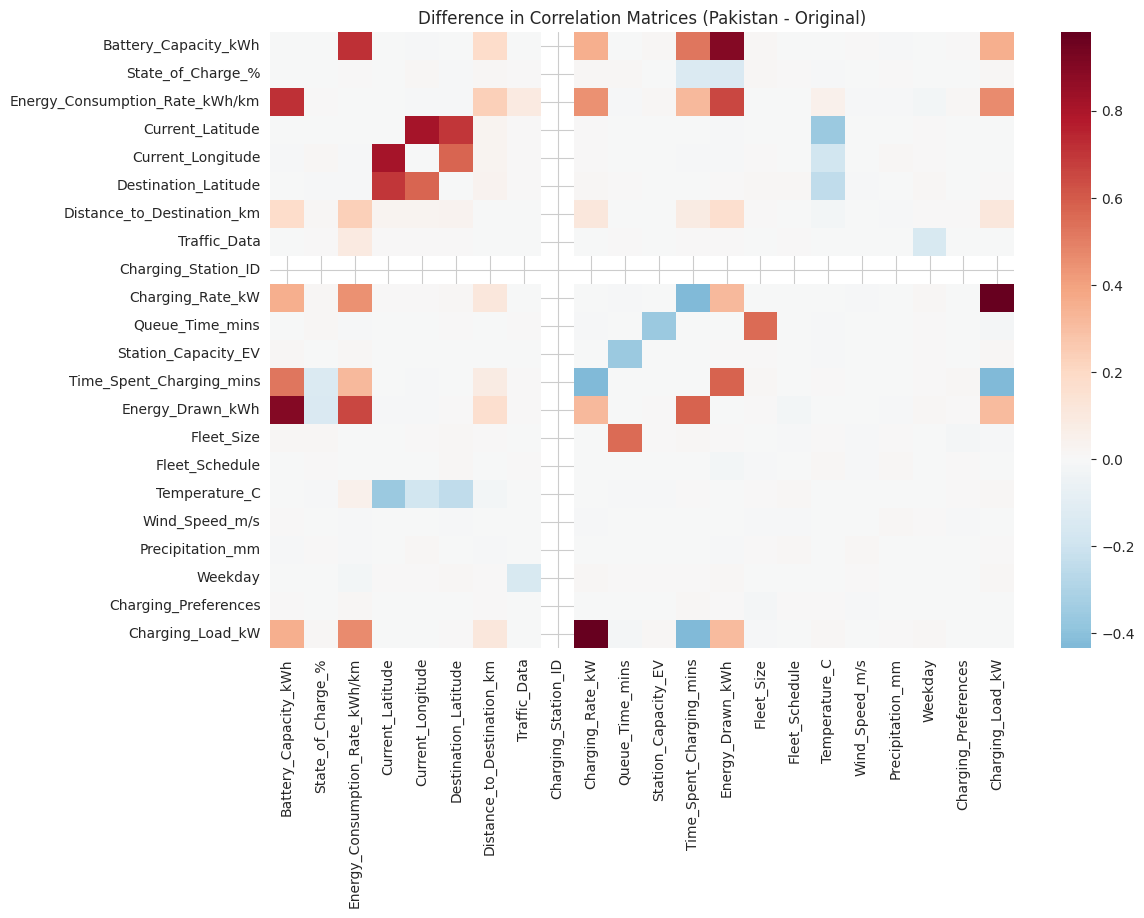

In [ ]:
import numpy as np

# Calculate correlation matrix for Pakistan dataset
pak_corr = pakistan_df[numerical_cols_pca].corr()

# Calculate correlation matrix for Original dataset
orig_corr = df_cleaned[numerical_cols_pca].corr()

# Compare the correlation of features with the target 'Charging_Load_kW'
pak_target_corr = pak_corr['Charging_Load_kW'].sort_values(ascending=False)
orig_target_corr = orig_corr['Charging_Load_kW'].sort_values(ascending=False)

comparison_df = pd.DataFrame({
    'Pakistan_Corr': pak_target_corr,
    'Original_Corr': orig_target_corr
})

print("Correlation with Charging_Load_kW Comparison:")
display(comparison_df)

# Visualization of the difference in correlations
plt.figure(figsize=(12, 8))
sns.heatmap(pak_corr - orig_corr, cmap='RdBu_r', center=0)
plt.title('Difference in Correlation Matrices (Pakistan - Original)')
plt.show()

### **11. Structural Identity Check**

We will now programmatically check if the column names, counts, and data types match between the training data and the Pakistan dataset.

In [ ]:
# Get columns used for PCA from both datasets
train_cols = set(numerical_cols_pca)
pak_cols = set(pakistan_df.columns)

# Check for missing or extra columns
missing_in_pak = train_cols - pak_cols
extra_in_pak = pak_cols - train_cols

print("--- Structural Consistency Check ---")
print(f"Columns missing in Pakistan dataset: {missing_in_pak if missing_in_pak else 'None'}")
print(f"Columns extra in Pakistan dataset: {extra_in_pak if extra_in_pak else 'None'}")

# Check Data Types for shared columns
shared_cols = list(train_cols.intersection(pak_cols))
dtypes_match = df_cleaned[shared_cols].dtypes.equals(pakistan_df[shared_cols].dtypes)

print(f"Data types match for all shared columns: {dtypes_match}")

if not dtypes_match:
    print("\nDatatype Mismatches:")
    for col in shared_cols:
        if df_cleaned[col].dtype != pakistan_df[col].dtype:
            print(f"- {col}: Train ({df_cleaned[col].dtype}) vs Pakistan ({pakistan_df[col].dtype})")

# Verify Shape for Model Feeding
print(f"\nExpected Input Features (PCA): {len(numerical_cols_pca)}")
print(f"Actual Available Features in Pakistan Data: {len(shared_cols)}")

--- Structural Consistency Check ---
Columns missing in Pakistan dataset: None
Columns extra in Pakistan dataset: {'Date_Time', 'Vehicle_ID', 'Road_Conditions', 'Destination_Longitude', 'Session_Start_Hour', 'Weather_Conditions'}
Data types match for all shared columns: False

Datatype Mismatches:
- Fleet_Size: Train (float64) vs Pakistan (int64)
- Charging_Preferences: Train (float64) vs Pakistan (int64)
- Weekday: Train (float64) vs Pakistan (int64)
- Traffic_Data: Train (float64) vs Pakistan (int64)
- Charging_Station_ID: Train (float64) vs Pakistan (int64)
- Station_Capacity_EV: Train (float64) vs Pakistan (int64)
- Fleet_Schedule: Train (float64) vs Pakistan (int64)

Expected Input Features (PCA): 22
Actual Available Features in Pakistan Data: 22


### **12. Fine-Tuning the Transformer on Pakistan Data**

To bridge the domain gap, we will use a portion of the Pakistan dataset to fine-tune the Transformer. We will use a small learning rate to avoid destroying the patterns learned from the larger original dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 1. Fit a NEW scaler and PCA specifically for the Pakistan data domain
pak_scaler = StandardScaler()
pak_scaled_full = pak_scaler.fit_transform(pakistan_df[numerical_cols_pca])

pak_pca = PCA(n_components=17)
pak_pc_values = pak_pca.fit_transform(pak_scaled_full)

# 2. Reshape for Transformer
X_pak_reshaped = pak_pc_values.reshape(pak_pc_values.shape[0], 1, pak_pc_values.shape[1])
y_pak_labels = pakistan_df['Charging_Load_kW'].values

# 3. Split the domain-adjusted data
X_pak_train, X_pak_test, y_pak_train, y_pak_test = train_test_split(
    X_pak_reshaped, y_pak_labels, test_size=0.9, random_state=RANDOM_SEED
)

# 4. Prepare EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 5. Fine-tune with domain-adjusted features
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
transformer_model.compile(loss='mse', optimizer=optimizer)

print("Starting Domain-Adjusted Fine-tuning (max 200 epochs)... ")
history_finetune = transformer_model.fit(
    X_pak_train,
    y_pak_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("Fine-tuning with new domain scaling and EarlyStopping completed.")

Starting Domain-Adjusted Fine-tuning (max 200 epochs)... 
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


115/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 969.1925

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 716.0778 - val_loss: 334.9384
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 170.2215 - val_loss: 68.7322
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 53.3996 - val_loss: 30.1310
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 30.1552 - val_loss: 17.9697
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 22.4290 - val_loss: 12.1162
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 17.0823 - val_loss: 9.2773
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14.3705 - val_loss: 7.5106
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.0183 - val_loss: 6.3231
Epoch 9/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 11.6215 - val_loss: 5.5872
Epoch 10/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10.0252 - val_loss: 5.0415
Epoch 11/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.8279 - val_loss: 4.6286
Epoch 12/200
125/125 ━━━━━━━━━━━━

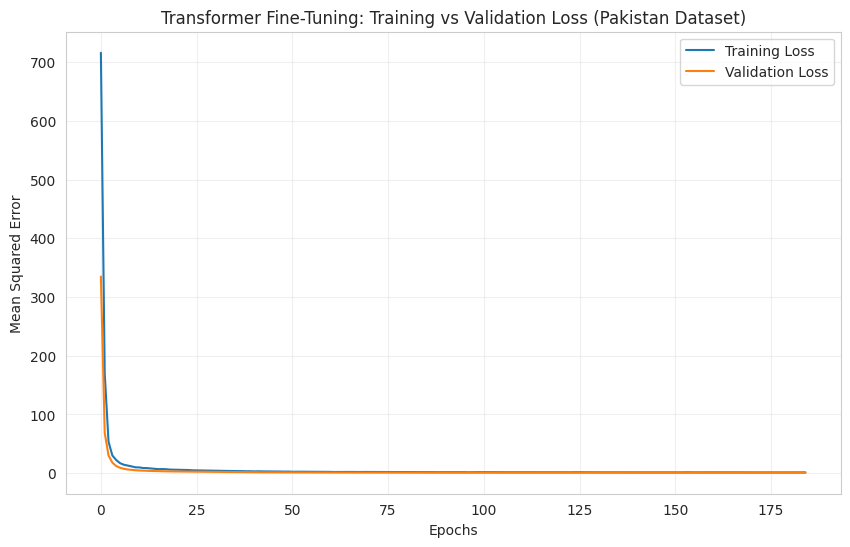

In [ ]:
import matplotlib.pyplot as plt

# Visualize Transformer fine-tuning history
plt.figure(figsize=(10, 6))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Transformer Fine-Tuning: Training vs Validation Loss (Pakistan Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **13. Final Evaluation after Fine-Tuning**

Now we evaluate the performance on the remaining 90% of the Pakistan dataset that the model has not seen during the fine-tuning stage.

In [ ]:
# 1. Predict on the Pakistan test set
y_pred_pak_final = transformer_model.predict(X_pak_test)

# 2. Evaluate metrics
rmse_pak_final = np.sqrt(mean_squared_error(y_pak_test, y_pred_pak_final))
mae_pak_final = mean_absolute_error(y_pak_test, y_pred_pak_final)
r2_pak_final = r2_score(y_pak_test, y_pred_pak_final)

print("--- Metrics on Pakistan Data AFTER Fine-Tuning ---")
print(f"Root Mean Squared Error (RMSE): {rmse_pak_final:.4f}")
print(f"Mean Absolute Error (MAE): {mae_pak_final:.4f}")
print(f"R-squared (R2): {r2_pak_final:.4f}")

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
--- Metrics on Pakistan Data AFTER Fine-Tuning ---
Root Mean Squared Error (RMSE): 0.9203
Mean Absolute Error (MAE): 0.6570
R-squared (R2): 0.9893


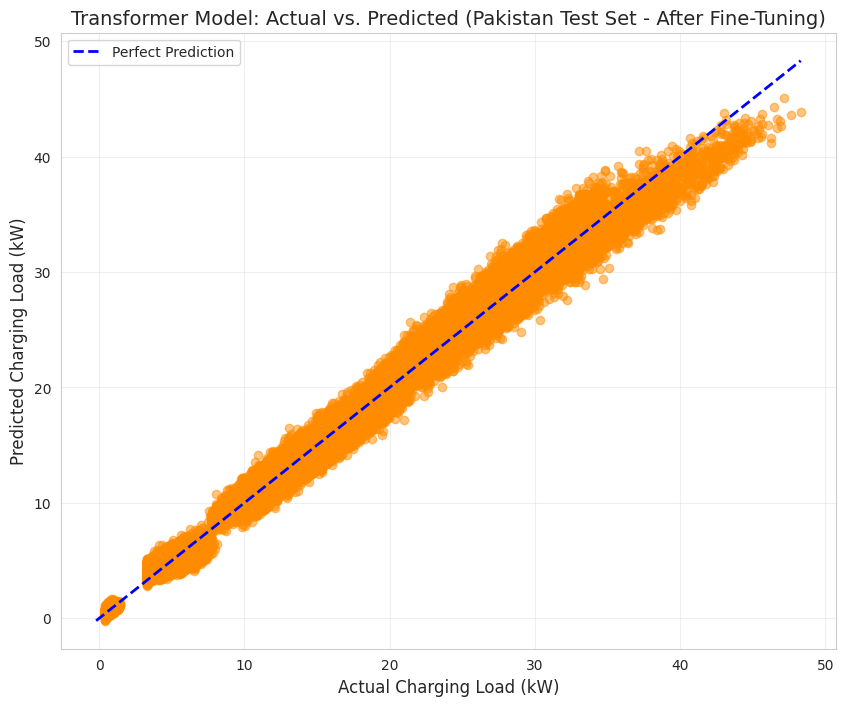

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions for the Transformer model on the Pakistan test set
y_pred_pak_flat = y_pred_pak_final.flatten()

plt.figure(figsize=(10, 8))
plt.scatter(y_pak_test, y_pred_pak_flat, alpha=0.5, color='darkorange')

# Add a 45-degree line for reference (Perfect Prediction)
max_val = max(y_pak_test.max(), y_pred_pak_flat.max())
min_val = min(y_pak_test.min(), y_pred_pak_flat.min())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Transformer Model: Actual vs. Predicted (Pakistan Test Set - After Fine-Tuning)', fontsize=14)
plt.xlabel('Actual Charging Load (kW)', fontsize=12)
plt.ylabel('Predicted Charging Load (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **14. Domain Transfer Comparison: Transformer Performance Scenario Analysis**

We will now visualize the performance of the Transformer model across two distinct scenarios:
1.  **Original Test Set:** Performance on the dataset it was originally trained on.
2.  **Pakistan Fine-Tuned:** Performance on the Pakistan dataset after domain-specific scaling and fine-tuning.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for scenario comparison (excluding zero-shot to maintain presentation clarity)
scenario_data = {
    'Scenario': ['Original', 'Pakistan Fine-Tuned'],
    'RMSE': [rmse_trans, rmse_pak_final],
    'MAE': [mae_trans, mae_pak_final],
    'R2': [r2_trans, r2_pak_final]
}

comparison_df = pd.DataFrame(scenario_data)

print("Final Performance Comparison Table:")
display(comparison_df)

Final Performance Comparison Table:


,Scenario,RMSE,MAE,R2
0,Original,3.51159,2.586936,0.874767
1,Pakistan Fine-Tuned,0.92032,0.657020,0.989303


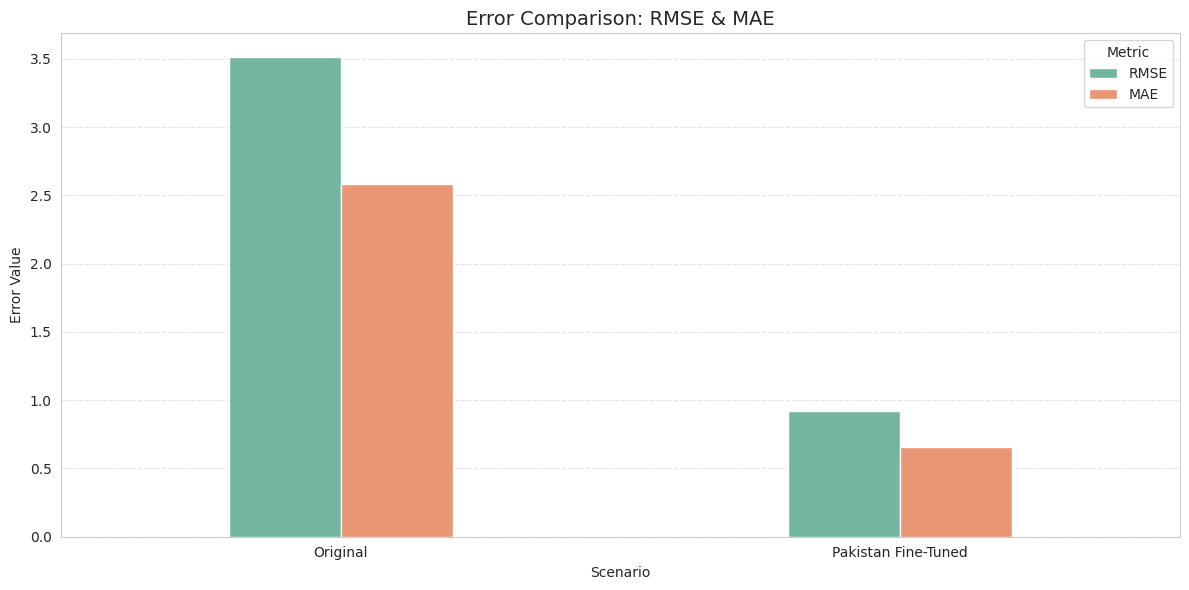

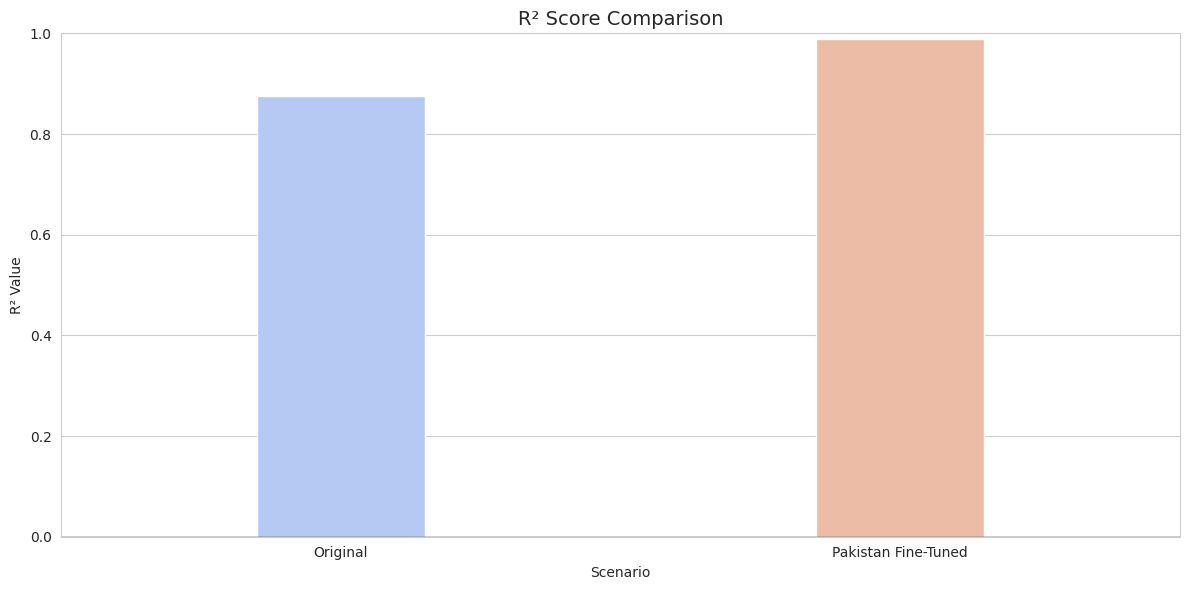

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt for plotting Error Metrics
plot_df = comparison_df.melt(id_vars='Scenario', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Value')

sns.set_style("whitegrid")

# Plot 1: RMSE and MAE (Separate Graph)
plt.figure(figsize=(12, 6))
sns.barplot(x='Scenario', y='Value', hue='Metric', data=plot_df, palette='Set2', width=0.4)
plt.title('Error Comparison: RMSE & MAE', fontsize=14)
plt.ylabel('Error Value')
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Plot 2: R2 Score (Separate Graph)
plt.figure(figsize=(12, 6))
sns.barplot(x='Scenario', y='R2', hue='Scenario', data=comparison_df, palette='coolwarm', legend=False, width=0.3)
plt.title('R² Score Comparison', fontsize=14)
plt.ylabel('R² Value')
plt.setp(plt.gca(), ylim=(0.0, 1.0)) # Changed to show the full R2 range (0 to 1)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()